# Exploratory Data Analysis (EDA)

**Project**: Intelligent Employee Task Allocation — DS-20 (Industry Explorer Track)  
**Client**: Cygnus One (Pvt) Ltd  
**Input**: `data/raw/Combined_Employee_Task_Data.csv` — 11,633 rows × 22 columns  

---

## Purpose of This Notebook

Perform a comprehensive Exploratory Data Analysis (EDA) on the combined employee–task dataset containing **11,633 rows** and **22 columns**.

The main objective of the EDA is to understand the dataset structure, data quality, employee/task distributions, relationships between variables, and patterns that may be useful for developing an **Employee–Task Allocation Recommendation System**.

---

## EDA Workflow Overview

| Step | Section | Focus |
|---|---|---|
| 1 | Dataset Overview | Structure, shape, data types, statistics |
| 2 | Data Quality Analysis | Missing values, duplicates, inconsistencies |
| 3 | Employee Analysis | Employee distributions, task counts per employee |
| 4 | Task Analysis | Task types, priorities, stages, project distributions |
| 5 | Time & Effort Analysis | Hours spent, planned vs actual, workload |
| 6 | Project Analysis | Project-level patterns, department involvement |
| 7 | Employee–Task Relationship | Who does what — core input for the recommendation model |
| 8 | Text Data Analysis | NLP-oriented exploration of description fields |
| 9 | Target Variable Analysis | Class distribution of `Employee_ID` |
| 10 | Correlation & Relationships | Numerical correlations, cross-tabulations |
| 11 | Data Integration Validation | Merge quality check from `Data_Preparation.ipynb` |
| 12 | Key Findings & Conclusions | EDA summary + preprocessing requirements |

---

## Import Libraries

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from collections import Counter

In [60]:
file_path = '../data/raw/Combined_Employee_Task_Data.csv'
df = pd.read_csv(file_path)

---

## Step 1: Dataset Overview

Start by examining the overall structure of the dataset.

**Tasks in this step:**
- Display the number of rows and columns.
- Display all column names.
- Display the first 5 and last 5 rows.
- Check the data types of all columns.
- Generate a basic statistical summary for numerical variables.
- Generate a summary of categorical variables.
- Identify numerical, categorical, date, text, and identifier columns.

In [61]:
print("--- Dataset Structure ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")
print("--- Column Names ---")
print(df.columns.tolist(), "\n")

--- Dataset Structure ---
Total Rows: 11633
Total Columns: 22

--- Column Names ---
['Timesheet_ID', 'Date', 'Task_ID', 'Task_Name', 'Work_Description', 'Hours_Spent', 'Project_Name', 'Employee_ID', 'Employee_Name', 'Employee_Department', 'Employee_Job_Position', 'Task_Description', 'Timesheet_Work_Logs', 'Original_Task_Description', 'Task_Priority', 'Estimated_Planned_Hours', 'Actual_Hours_Spent', 'Timesheet_Logs_Count', 'Task_Stage', 'Created_Date', 'Deadline_Date', 'All_Collaborating_Employees'] 



In [62]:
print("--- First 5 Rows ---")
display(df.head())
print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Timesheet_ID,Date,Task_ID,Task_Name,Work_Description,Hours_Spent,Project_Name,Employee_ID,Employee_Name,Employee_Department,...,Timesheet_Work_Logs,Original_Task_Description,Task_Priority,Estimated_Planned_Hours,Actual_Hours_Spent,Timesheet_Logs_Count,Task_Stage,Created_Date,Deadline_Date,All_Collaborating_Employees
0,TS-12331,2026-09-14,TSK-1640,Odoo SH Maintain,db backup and restore in test,0.25,Hovael Project,EMP-11,W M I L Wijesinghe,Research and Development (R&D),...,Add addons t the server | Get backup from live...,NaN,Low,0.0,14.25,27,Project Preparation,2026-02-05,NaN,W M I L Wijesinghe
1,TS-12330,2026-09-14,TSK-1881,Odoo sh Maintain,db backup and restore in test,0.25,CEYLON ECO SPICES,EMP-11,W M I L Wijesinghe,Research and Development (R&D),...,add addon and test | get odoo sh live ackup an...,NaN,Low,0.0,6.50,13,Developments,2026-03-19,NaN,W M I L Wijesinghe
2,TS-12329,2026-09-14,TSK-182,Odoo.SH Maintaing,add addons,0.25,Mihiri Bakemart (Pvt)Ltd - Development,EMP-11,W M I L Wijesinghe,Research and Development (R&D),...,add all addon and build and test on the odoo s...,NaN,Low,0.0,40.75,29,Ongoing,2025-06-09,NaN,W M I L Wijesinghe
3,TS-12328,2026-09-14,TSK-2884,Development Meeting,/,0.00,Cygnus One,EMP-55,Malshi Jayanthi,Colombo Branch,...,intern development hoveal project meeting | me...,NaN,Low,0.0,9.42,13,Miscellaneous,2026-07-06,NaN,"W M I L Wijesinghe, K R V Dias, A R M S Madusa..."
4,TS-12327,2026-09-14,TSK-405,Other Tasks (Mention on description),get privillages to charith's new github accoun...,0.50,Cygnus One,EMP-11,W M I L Wijesinghe,Research and Development (R&D),...,self ssl setup on vps | Preparing Report List ...,NaN,Low,0.0,162.18,69,Miscellaneous,2025-07-14,NaN,"H.M.C.S Thilakarathna, Sadaruwan Bandara, L H ..."



--- Last 5 Rows ---


,Timesheet_ID,Date,Task_ID,Task_Name,Work_Description,Hours_Spent,Project_Name,Employee_ID,Employee_Name,Employee_Department,...,Timesheet_Work_Logs,Original_Task_Description,Task_Priority,Estimated_Planned_Hours,Actual_Hours_Spent,Timesheet_Logs_Count,Task_Stage,Created_Date,Deadline_Date,All_Collaborating_Employees
11628,TS-50,2025-06-02,TSK-89,presales fields,dealer field for pre sale,3.0,Asil - Development,EMP-10,M H R Chandrasoma,Research and Development (R&D),...,dealer field for pre sale | pricelist and supp...,NaN,Low,0.0,8.0,2,In-Development,2025-06-02,NaN,M H R Chandrasoma
11629,TS-49,2025-06-02,TSK-2,Meeting,Mihira UAT,6.0,Internal,EMP-18,E I S Dhananjaya,Business Solution,...,Analysis | Mihira UAT | at the main office Kur...,NaN,Low,0.0,47.0,25,Internal,2025-04-16,NaN,"Administrator, A R M S Madusanka, R P L Shanth..."
11630,TS-127,2025-06-01,TSK-228,User Traning,Traning the user vise,8.0,Malindu Dairy Pvt Ltd - Implementation,EMP-14,R P L Shantha,Business Solution,...,Traning the user vise | Mobile App development...,NaN,Low,0.0,44.5,8,Project Preparation,2025-06-13,NaN,"G L Sachini, R P L Shantha"
11631,TS-2,2025-04-16,TSK-2,Meeting,Analysis,0.0,Internal,EMP-1,Administrator,Administration,...,Analysis | Mihira UAT | at the main office Kur...,NaN,Low,0.0,47.0,25,Internal,2025-04-16,NaN,"Administrator, A R M S Madusanka, R P L Shanth..."
11632,TS-1,2025-04-16,TSK-1,Training,Analysis,0.0,Internal,EMP-1,Administrator,Administration,...,Analysis | Inventory Module 'How to work locat...,NaN,Low,0.0,23.0,8,Internal,2025-04-16,NaN,"H M N S K Herath, Administrator, D.R.perera, A..."


In [63]:
print("\n--- Data Types and Non-Null Counts ---")
df.info()


--- Data Types and Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 11633 entries, 0 to 11632
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Timesheet_ID                 11633 non-null  str    
 1   Date                         11633 non-null  str    
 2   Task_ID                      11633 non-null  str    
 3   Task_Name                    11633 non-null  str    
 4   Work_Description             11632 non-null  str    
 5   Hours_Spent                  11633 non-null  float64
 6   Project_Name                 11633 non-null  str    
 7   Employee_ID                  11633 non-null  str    
 8   Employee_Name                11633 non-null  str    
 9   Employee_Department          11556 non-null  str    
 10  Employee_Job_Position        11633 non-null  str    
 11  Task_Description             11633 non-null  str    
 12  Timesheet_Work_Logs          11559 non-null  

In [64]:
print("\n--- Statistical Summary (Numerical Variables) ---")
display(df.describe())


--- Statistical Summary (Numerical Variables) ---


,Hours_Spent,Estimated_Planned_Hours,Actual_Hours_Spent,Timesheet_Logs_Count
count,11633.000000,11633.000000,11633.000000,11633.000000
mean,3.613622,10.157871,131.112871,50.152239
std,2.749432,24.315339,239.755017,97.999387
min,0.000000,0.000000,0.000000,1.000000
25%,1.000000,0.000000,14.000000,4.000000
50%,2.500000,0.000000,30.750000,9.000000
75%,6.000000,16.000000,102.750000,38.000000
max,24.000000,552.000000,1070.870000,441.000000


In [65]:
print("\n--- Statistical Summary (Categorical Variables) ---")
display(df.describe(include=['object']))


--- Statistical Summary (Categorical Variables) ---


/tmp/ipykernel_275556/2010995118.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object']))


,Timesheet_ID,Date,Task_ID,Task_Name,Work_Description,Project_Name,Employee_ID,Employee_Name,Employee_Department,Employee_Job_Position,Task_Description,Timesheet_Work_Logs,Original_Task_Description,Task_Priority,Task_Stage,Created_Date,Deadline_Date,All_Collaborating_Employees
count,11633,11633,11633,11633,11632,11633,11633,11633,11556,11633,11633,11559,68,11633,11633,11633,1621,11633
unique,11633,397,2442,1886,9696,91,49,49,7,21,2440,2364,22,2,28,337,155,317
top,TS-12331,2026-08-17,TSK-183,Project Manager Support,/,Cygnus One,EMP-5,J A P Swarnamali,Research and Development (R&D),Associate Software Engineer,Meeting. Work Details: Mihiri development plan...,Mihiri development plan and requirmnets analys...,Down payment - 50%,Low,Miscellaneous,2025-06-09,2026-07-31,M H R Chandrasoma
freq,1,73,441,577,462,3432,1010,1010,4787,1866,441,441,11,10918,3252,480,107,831


In [66]:
column_categories = {
    "Identifiers (Keys/References)": [
        "Timesheet_ID", "Task_ID", "Employee_ID", "Employee_Name"
    ],
    "Date Variables": [
        "Date", "Created_Date", "Deadline_Date"
    ],
    "Numerical Variables": [
        "Hours_Spent", "Estimated_Planned_Hours", "Actual_Hours_Spent", "Timesheet_Logs_Count"
    ],
    "Text/NLP Variables": [
        "Work_Description", "Task_Description", "Timesheet_Work_Logs", "Original_Task_Description"
    ],
    "Categorical Variables": [
        "Task_Name", "Project_Name", "Employee_Department", "Employee_Job_Position", 
        "Task_Priority", "Task_Stage", "All_Collaborating_Employees"
    ]
}
print("\n--- Column Feature Categorization ---")
for category, cols in column_categories.items():
    print(f"\n{category} ({len(cols)}):")
    for col in cols:
        print(f" - {col}")


--- Column Feature Categorization ---

Identifiers (Keys/References) (4):
 - Timesheet_ID
 - Task_ID
 - Employee_ID
 - Employee_Name

Date Variables (3):
 - Date
 - Created_Date
 - Deadline_Date

Numerical Variables (4):
 - Hours_Spent
 - Estimated_Planned_Hours
 - Actual_Hours_Spent
 - Timesheet_Logs_Count

Text/NLP Variables (4):
 - Work_Description
 - Task_Description
 - Timesheet_Work_Logs
 - Original_Task_Description

Categorical Variables (7):
 - Task_Name
 - Project_Name
 - Employee_Department
 - Employee_Job_Position
 - Task_Priority
 - Task_Stage
 - All_Collaborating_Employees


--- Missing Values Summary ---


,Missing_Count,Missing_Percentage (%)
Original_Task_Description,11565,99.415456
Deadline_Date,10012,86.065503
Employee_Department,77,0.661910
Timesheet_Work_Logs,74,0.636121
Work_Description,1,0.008596



--- Columns with >30% Missing Values ---


,Missing_Count,Missing_Percentage (%)
Original_Task_Description,11565,99.415456
Deadline_Date,10012,86.065503


/tmp/ipykernel_275556/2758504268.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data['Missing_Percentage (%)'], y=missing_data.index, palette='Reds_r')



Missing values plot saved to: ../results/figures/EDA_Missing_Values_Bar.png


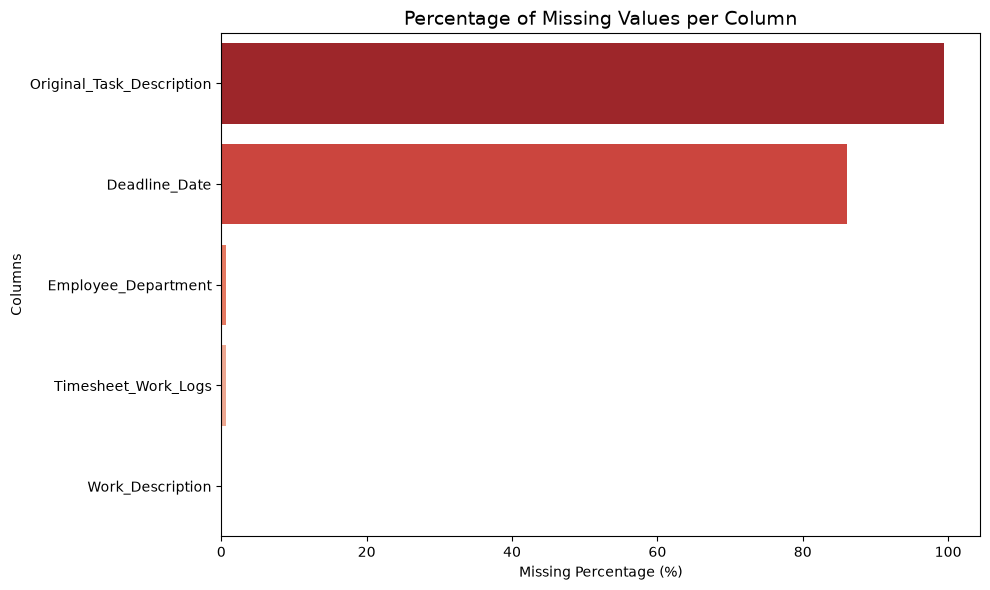

In [67]:
os.makedirs('../results/figures', exist_ok=True)
missing_data = df.isnull().sum().to_frame(name='Missing_Count')
missing_data['Missing_Percentage (%)'] = (missing_data['Missing_Count'] / len(df)) * 100
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(by='Missing_Percentage (%)', ascending=False)
print("--- Missing Values Summary ---")
display(missing_data)
high_missing = missing_data[missing_data['Missing_Percentage (%)'] > 30]
print("\n--- Columns with >30% Missing Values ---")
display(high_missing)
if not missing_data.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data['Missing_Percentage (%)'], y=missing_data.index, palette='Reds_r')
    plt.title('Percentage of Missing Values per Column', fontsize=14)
    plt.xlabel('Missing Percentage (%)')
    plt.ylabel('Columns')
    plt.tight_layout()
    save_path_missing = '../results/figures/EDA_Missing_Values_Bar.png'
    plt.savefig(save_path_missing, dpi=300)
    print(f"\nMissing values plot saved to: {save_path_missing}")
    plt.show()
else:
    print("\nNo missing values found in the dataset.")

---

## Step 2: Data Quality Analysis

Check the quality and completeness of the combined dataset.

**Tasks in this step:**
- Calculate missing-value counts and percentages for every column.
- Identify columns with a high percentage of missing values.
- Check for duplicate rows.
- Check for duplicate `Task_ID` values and `Timesheet_ID` values.
- Check whether `Employee_ID` consistently maps to the same employee name, department, and job position.
- Check whether `Task_ID` is associated with multiple employees or multiple timesheet records.
- Identify inconsistent or invalid values.
- Check for unusual values in numerical columns such as `Hours_Spent`, `Estimated_Planned_Hours`, and `Actual_Hours_Spent`.

In [68]:
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows in dataset: {total_duplicates}")
ts_duplicates = df['Timesheet_ID'].duplicated().sum()
print(f"Duplicate Timesheet_ID values: {ts_duplicates}")
task_duplicates = df['Task_ID'].duplicated().sum()
unique_tasks = df['Task_ID'].nunique()
print(f"Duplicate Task_ID entries (Timesheet Logs): {task_duplicates}")
print(f"Total Unique Tasks: {unique_tasks}")

Total duplicate rows in dataset: 0
Duplicate Timesheet_ID values: 0
Duplicate Task_ID entries (Timesheet Logs): 9191
Total Unique Tasks: 2442


In [69]:
emp_consistency = df.groupby('Employee_ID').agg({
    'Employee_Name': 'nunique',
    'Employee_Department': 'nunique',
    'Employee_Job_Position': 'nunique'
})
inconsistent_emps = emp_consistency[
    (emp_consistency['Employee_Name'] > 1) | 
    (emp_consistency['Employee_Department'] > 1) | 
    (emp_consistency['Employee_Job_Position'] > 1)
]
print("--- Employee Consistency Check ---")
if inconsistent_emps.empty:
    print("All Employee_IDs consistently map to a single Name, Department, and Job Position.")
else:
    print("Warning: Inconsistencies found in Employee mapping:")
    display(inconsistent_emps)
task_associations = df.groupby('Task_ID').agg({
    'Timesheet_ID': 'count',
    'Employee_ID': 'nunique'
}).rename(columns={'Timesheet_ID': 'Timesheet_Count', 'Employee_ID': 'Distinct_Employees'})
multi_emp_tasks = task_associations[task_associations['Distinct_Employees'] > 1]
print(f"\n--- Task Association Check ---")
print(f"Tasks with multiple timesheet records: {(task_associations['Timesheet_Count'] > 1).sum()}")
print(f"Tasks worked on by multiple distinct employees: {len(multi_emp_tasks)}")

--- Employee Consistency Check ---
All Employee_IDs consistently map to a single Name, Department, and Job Position.

--- Task Association Check ---
Tasks with multiple timesheet records: 1565
Tasks worked on by multiple distinct employees: 442


--- Invalid Numerical Values Check ---
Hours_Spent: 0 negative values, 54 zero values
Estimated_Planned_Hours: 0 negative values, 7274 zero values
Actual_Hours_Spent: 0 negative values, 8 zero values


/tmp/ipykernel_275556/1054961524.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Metric', y='Hours', palette='viridis')



Outliers boxplot saved to: ../results/figures/EDA_Numerical_Outliers_Boxplot.png


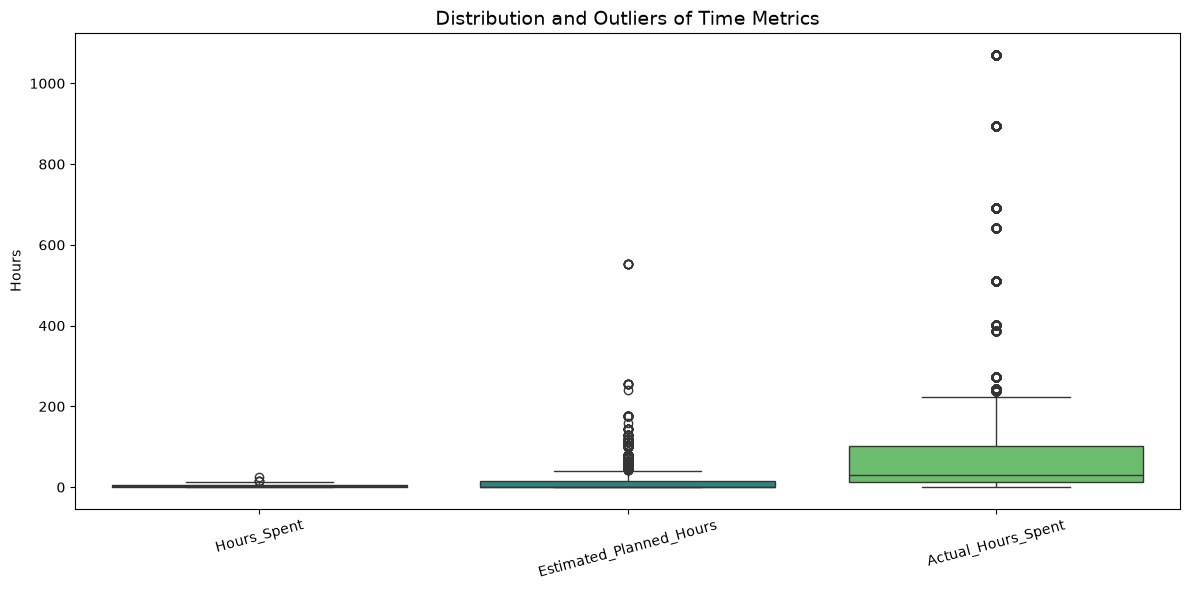


--- Extreme Outliers (> 99th Percentile) ---
Hours_Spent: 64 records exceed 9.00 hours
Estimated_Planned_Hours: 117 records exceed 117.44 hours
Actual_Hours_Spent: 0 records exceed 1070.87 hours


In [70]:
num_cols = ['Hours_Spent', 'Estimated_Planned_Hours', 'Actual_Hours_Spent']
print("--- Invalid Numerical Values Check ---")
for col in num_cols:
    negative_count = (df[col] < 0).sum()
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {negative_count} negative values, {zero_count} zero values")
plt.figure(figsize=(12, 6))
df_melted = df.melt(value_vars=num_cols, var_name='Metric', value_name='Hours')
sns.boxplot(data=df_melted, x='Metric', y='Hours', palette='viridis')
plt.title('Distribution and Outliers of Time Metrics', fontsize=14)
plt.ylabel('Hours')
plt.xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
save_path_outliers = '../results/figures/EDA_Numerical_Outliers_Boxplot.png'
plt.savefig(save_path_outliers, dpi=300)
print(f"\nOutliers boxplot saved to: {save_path_outliers}")
plt.show()
print("\n--- Extreme Outliers (> 99th Percentile) ---")
for col in num_cols:
    threshold = df[col].quantile(0.99)
    outlier_count = (df[col] > threshold).sum()
    print(f"{col}: {outlier_count} records exceed {threshold:.2f} hours")

---

## Step 3: Employee Analysis

Analyze the employee-related information.

**Tasks in this step:**
- Count the number of unique employees.
- Analyze the number of tasks/timesheet records associated with each employee.
- Analyze employee distribution by department.
- Analyze employee distribution by job position.
- Identify employees with very high or very low numbers of assigned tasks.
- Analyze the relationship between department, job position, and task assignments.
- Identify whether some employees dominate the historical task assignments.

**Visualizations:**
- Employee task-count distribution.
- Department distribution.
- Job-position distribution.
- Top employees by number of assigned tasks.

In [71]:
total_employees = df['Employee_ID'].nunique()
print(f"Total Unique Employees: {total_employees}\n")
logs_per_employee = df['Employee_ID'].value_counts().reset_index()
logs_per_employee.columns = ['Employee_ID', 'Timesheet_Logs']
emp_details = df[['Employee_ID', 'Employee_Name']].drop_duplicates()
logs_per_employee = logs_per_employee.merge(emp_details, on='Employee_ID', how='left')
print("--- Timesheet Records per Employee (Top 10) ---")
display(logs_per_employee.head(10))

Total Unique Employees: 49

--- Timesheet Records per Employee (Top 10) ---


,Employee_ID,Timesheet_Logs,Employee_Name
0,EMP-5,1010,J A P Swarnamali
1,EMP-10,959,M H R Chandrasoma
2,EMP-11,946,W M I L Wijesinghe
3,EMP-17,604,G L Sachini
4,EMP-4,547,H.M.C.S Thilakarathna
5,EMP-16,528,W A R M Prashansa
6,EMP-12,516,K P J Rajindi
7,EMP-27,508,R M VP UDAGAMA
8,EMP-7,498,L H P S S Pathirana
9,EMP-21,457,W M A P Wanninayaka


--- Employee Distribution by Department ---


,Headcount
Employee_Department,
Research and Development (R&D),14
Business Solution,14
Colombo Branch,8
Support & Maintenance,6
Sales & Marketing,2
Administration,2
Quality assurance (QA),1



--- Employee Distribution by Job Position ---


,Headcount
Employee_Job_Position,
Associate Functional Consultant,8
Software Engineer,8
Odoo Functional Consultant,5
Associate Software Engineer,3
Training Software Engineer - Internship,3
Team Lead - Research and Development (R&D),2
Project Manager,2
Support Intern,2
Training Odoo Functional Consultant,2


/tmp/ipykernel_275556/4120997872.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_275556/4120997872.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(



Employee distribution plots saved to: ../results/figures/EDA_Employee_Demographics.png


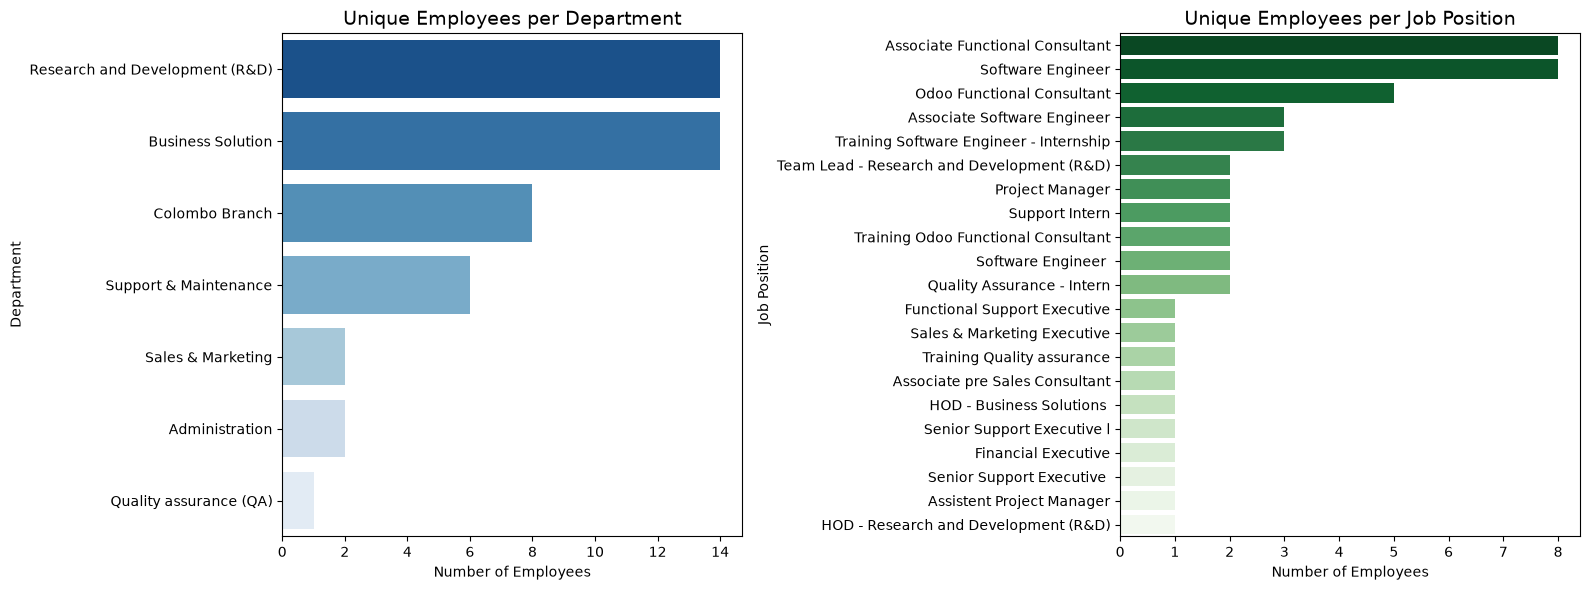

In [72]:
unique_emps_df = df[['Employee_ID', 'Employee_Name', 'Employee_Department', 'Employee_Job_Position']].drop_duplicates(subset=['Employee_ID'])
print("--- Employee Distribution by Department ---")
display(unique_emps_df['Employee_Department'].value_counts().to_frame(name='Headcount'))
print("\n--- Employee Distribution by Job Position ---")
display(unique_emps_df['Employee_Job_Position'].value_counts().to_frame(name='Headcount'))
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.countplot(
    y='Employee_Department', 
    data=unique_emps_df, 
    order=unique_emps_df['Employee_Department'].value_counts().index, 
    palette='Blues_r'
)
plt.title('Unique Employees per Department', fontsize=14)
plt.xlabel('Number of Employees')
plt.ylabel('Department')
plt.subplot(1, 2, 2)
sns.countplot(
    y='Employee_Job_Position', 
    data=unique_emps_df, 
    order=unique_emps_df['Employee_Job_Position'].value_counts().index, 
    palette='Greens_r'
)
plt.title('Unique Employees per Job Position', fontsize=14)
plt.xlabel('Number of Employees')
plt.ylabel('Job Position')
plt.tight_layout()
save_path_emp_dist = '../results/figures/EDA_Employee_Demographics.png'
plt.savefig(save_path_emp_dist, dpi=300)
print(f"\nEmployee distribution plots saved to: {save_path_emp_dist}")
plt.show()

--- Top 5 Dominant Employees (Highest Task Load) ---


,Employee_ID,Timesheet_Logs,Employee_Name,Percentage_of_Total_Work (%)
0,EMP-5,1010,J A P Swarnamali,8.682197
1,EMP-10,959,M H R Chandrasoma,8.243789
2,EMP-11,946,W M I L Wijesinghe,8.132038
3,EMP-17,604,G L Sachini,5.192126
4,EMP-4,547,H.M.C.S Thilakarathna,4.702140



--- Bottom 5 Employees (Lowest Task Load) ---


,Employee_ID,Timesheet_Logs,Employee_Name,Percentage_of_Total_Work (%)
44,EMP-59,13,S.D.Dias,0.111751
45,EMP-24,9,H D A M Jayasinghe,0.077366
46,EMP-25,6,Gimhani Lakna,0.051577
47,EMP-67,2,Maleesha Dilshan Kavindya,0.017192
48,EMP-1,2,Administrator,0.017192


/tmp/ipykernel_275556/3770632689.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



Employee dominance plot saved to: ../results/figures/EDA_Employee_Dominance.png


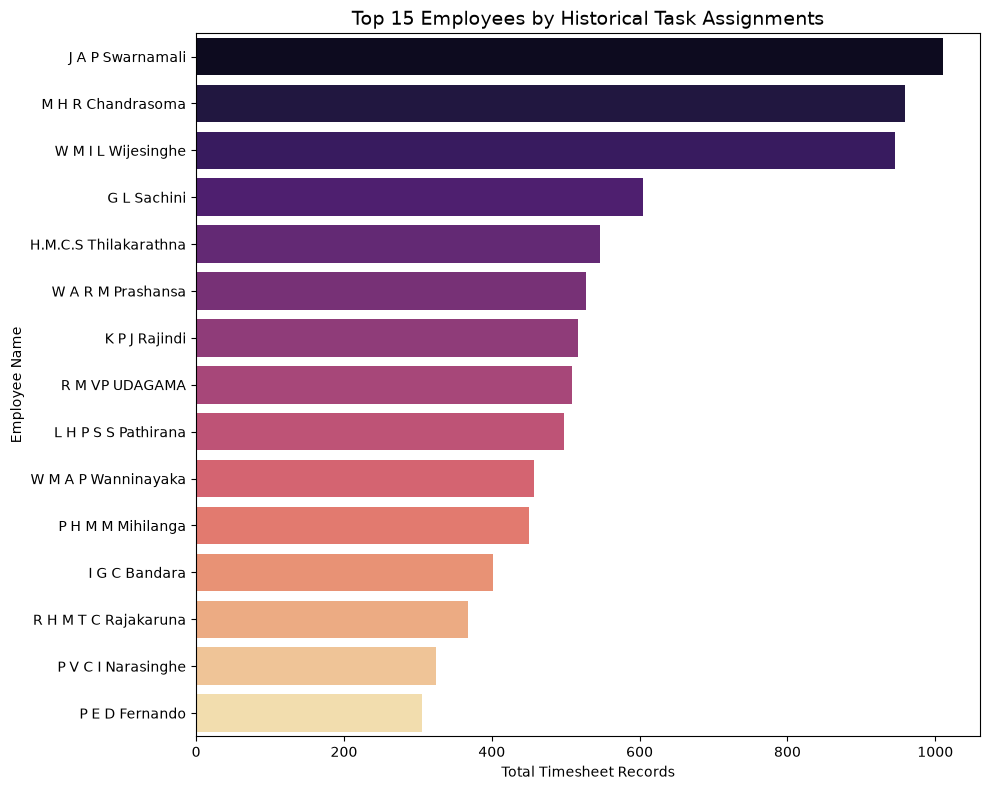

In [73]:
total_logs = len(df)
logs_per_employee['Percentage_of_Total_Work (%)'] = (logs_per_employee['Timesheet_Logs'] / total_logs) * 100
print("--- Top 5 Dominant Employees (Highest Task Load) ---")
display(logs_per_employee.head(5))
print("\n--- Bottom 5 Employees (Lowest Task Load) ---")
display(logs_per_employee.tail(5))
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Timesheet_Logs', 
    y='Employee_Name', 
    data=logs_per_employee.head(15), 
    palette='magma'
)
plt.title('Top 15 Employees by Historical Task Assignments', fontsize=14)
plt.xlabel('Total Timesheet Records')
plt.ylabel('Employee Name')
plt.tight_layout()
save_path_dominance = '../results/figures/EDA_Employee_Dominance.png'
plt.savefig(save_path_dominance, dpi=300)
print(f"\nEmployee dominance plot saved to: {save_path_dominance}")
plt.show()

--- Task Volume by Department and Job Position (Top Combinations) ---


,Employee_Department,Employee_Job_Position,Total_Timesheet_Logs
13,Research and Development (R&D),Associate Software Engineer,1866
5,Business Solution,Odoo Functional Consultant,1448
17,Research and Development (R&D),Team Lead - Research and Development (R&D),1444
3,Business Solution,Associate Functional Consultant,1162
4,Business Solution,HOD - Business Solutions,1010
18,Research and Development (R&D),Training Software Engineer - Internship,670
23,Support & Maintenance,Senior Support Executive,547
24,Support & Maintenance,Senior Support Executive l,528
21,Support & Maintenance,Functional Support Executive,516
16,Research and Development (R&D),Software Engineer,484



Cross-tabulation heatmap saved to: ../results/figures/EDA_Dept_Job_Heatmap.png


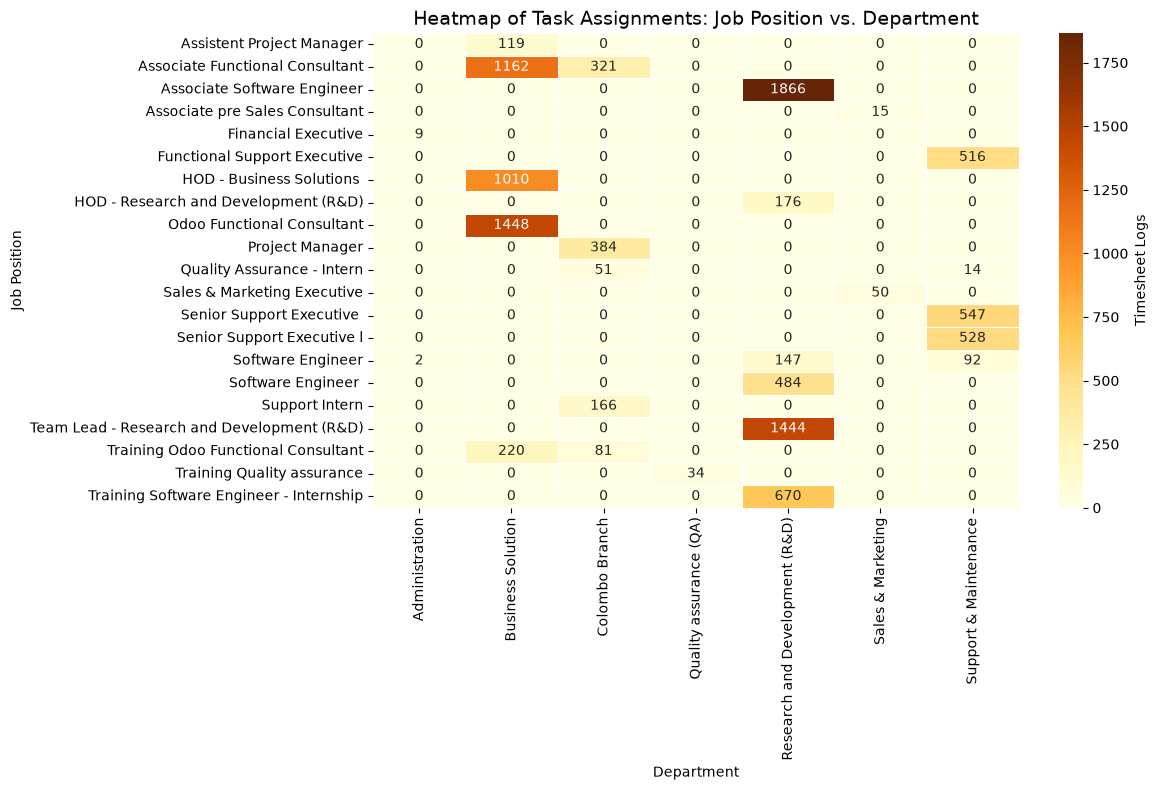

In [74]:
dept_job_tasks = df.groupby(['Employee_Department', 'Employee_Job_Position']).size().reset_index(name='Total_Timesheet_Logs')
dept_job_tasks = dept_job_tasks.sort_values(by='Total_Timesheet_Logs', ascending=False)
print("--- Task Volume by Department and Job Position (Top Combinations) ---")
display(dept_job_tasks.head(10))
pivot_tasks = dept_job_tasks.pivot(
    index='Employee_Job_Position', 
    columns='Employee_Department', 
    values='Total_Timesheet_Logs'
).fillna(0)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_tasks, annot=True, fmt=".0f", cmap="YlOrBr", linewidths=.5, cbar_kws={'label': 'Timesheet Logs'})
plt.title('Heatmap of Task Assignments: Job Position vs. Department', fontsize=14)
plt.ylabel('Job Position')
plt.xlabel('Department')
plt.tight_layout()
save_path_heatmap = '../results/figures/EDA_Dept_Job_Heatmap.png'
plt.savefig(save_path_heatmap, dpi=300)
print(f"\nCross-tabulation heatmap saved to: {save_path_heatmap}")
plt.show()

---

## Step 4: Task Analysis

Analyze the task-related information.

**Tasks in this step:**
- Count unique tasks.
- Analyze task frequency.
- Analyze task titles/names.
- Analyze task descriptions.
- Analyze task priority distribution.
- Analyze task stage distribution.
- Analyze project distribution.
- Identify the most common projects and tasks.
- Examine how tasks are distributed across employees.

**Visualizations:**
- Task priority distribution.
- Task stage distribution.
- Project distribution.
- Top task types.
- Tasks per project.

Total Unique Tasks (by Task_ID): 2442

--- Top 10 Most Common Task Names ---


,Frequency
Task_Name,
Project Manager Support,577
Meeting,522
Monitor and support live environment,376
Self Study,248
Intern Training,244
Functional Support,210
Development Meeting,191
Support,174
System Design (Database Design) as per the Blueprint,135


/tmp/ipykernel_275556/3495238370.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tasks.values, y=top_tasks.index, palette='viridis')


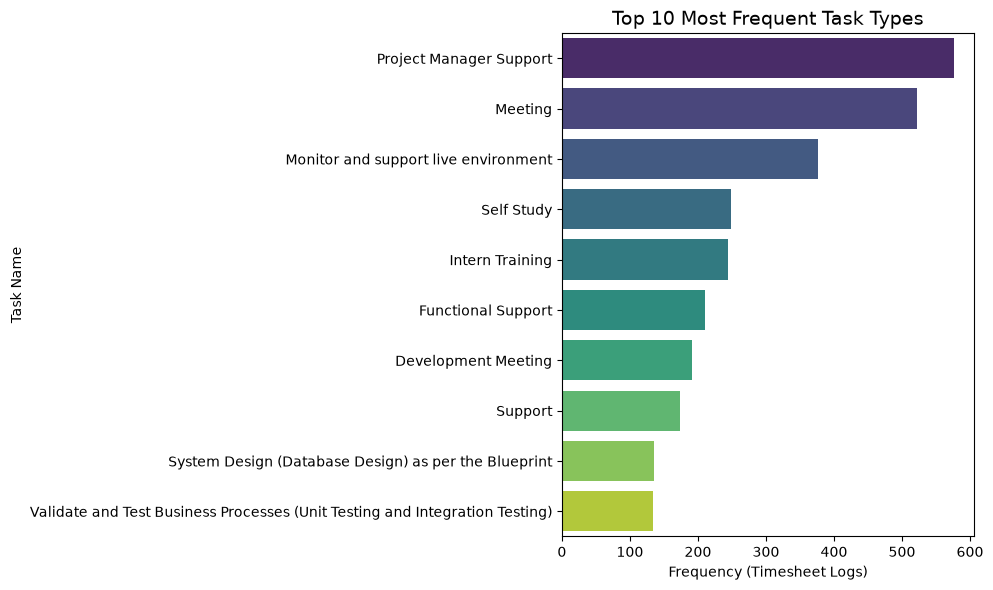

In [75]:
unique_tasks = df['Task_ID'].nunique()
print(f"Total Unique Tasks (by Task_ID): {unique_tasks}")
top_tasks = df['Task_Name'].value_counts().head(10)
print("\n--- Top 10 Most Common Task Names ---")
display(top_tasks.to_frame(name='Frequency'))
plt.figure(figsize=(10, 6))
sns.barplot(x=top_tasks.values, y=top_tasks.index, palette='viridis')
plt.title('Top 10 Most Frequent Task Types', fontsize=14)
plt.xlabel('Frequency (Timesheet Logs)')
plt.ylabel('Task Name')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Top_Task_Types.png', dpi=300)
plt.show()


--- Task Description Word Count Statistics ---


,Description_Word_Count
count,11633.000000
mean,315.710221
std,611.487997
min,4.000000
25%,28.000000
50%,67.000000
75%,229.000000
max,2415.000000


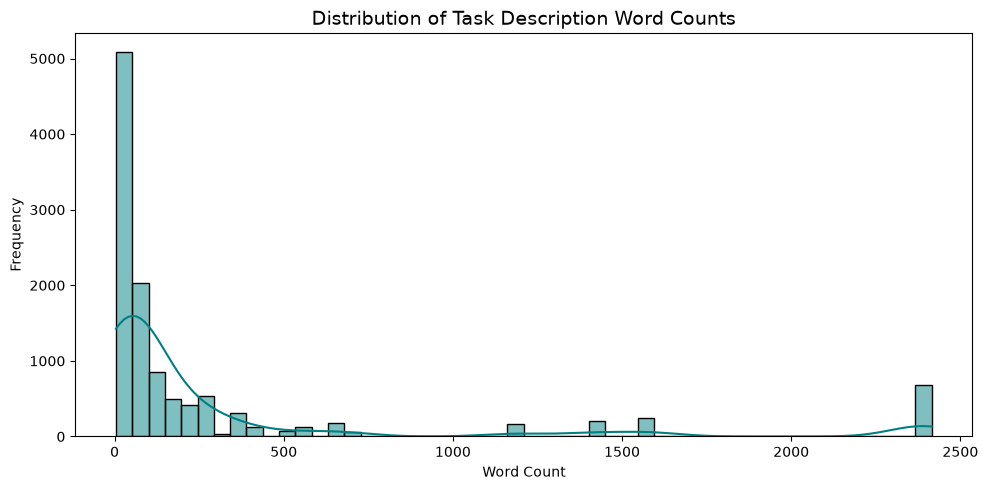

In [76]:
df['Description_Word_Count'] = df['Task_Description'].dropna().apply(lambda x: len(str(x).split()))
print("\n--- Task Description Word Count Statistics ---")
display(df['Description_Word_Count'].describe().to_frame())
plt.figure(figsize=(10, 5))
sns.histplot(df['Description_Word_Count'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribution of Task Description Word Counts', fontsize=14)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Task_Description_Length.png', dpi=300)
plt.show()


--- Task Priority Distribution ---


,Count
Task_Priority,
Low,10918
Normal,715


/tmp/ipykernel_275556/695100487.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


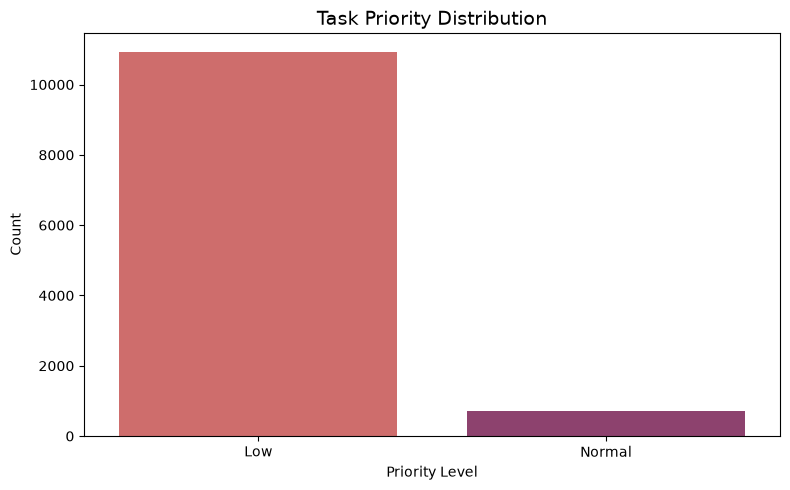

In [77]:
print("\n--- Task Priority Distribution ---")
display(df['Task_Priority'].value_counts().to_frame(name='Count'))
plt.figure(figsize=(8, 5))
sns.countplot(
    x='Task_Priority', 
    data=df, 
    order=df['Task_Priority'].value_counts().index, 
    palette='flare'
)
plt.title('Task Priority Distribution', fontsize=14)
plt.xlabel('Priority Level')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Task_Priority_Distribution.png', dpi=300)
plt.show()


--- Top 10 Task Stages Distribution ---


,Count
Task_Stage,
Miscellaneous,3252
Project Preparation,1547
Developments,1146
To Do,896
Go-Live and Support,851
Project Realization,586
In-Development,455
Development,449
Business Blueprint,381


/tmp/ipykernel_275556/4276174816.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


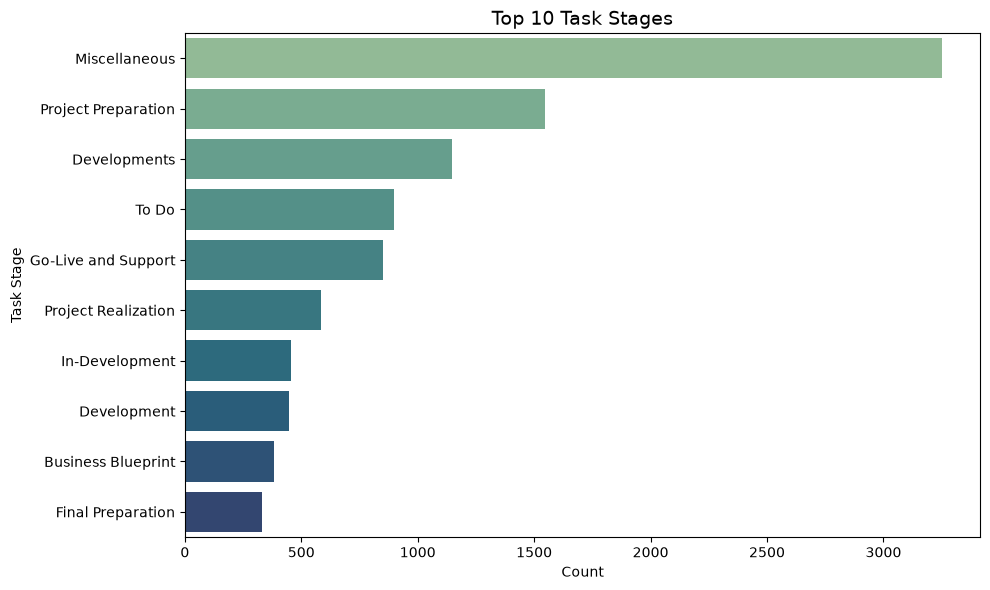

In [78]:
print("\n--- Top 10 Task Stages Distribution ---")
display(df['Task_Stage'].value_counts().head(10).to_frame(name='Count'))
plt.figure(figsize=(10, 6))
sns.countplot(
    y='Task_Stage', 
    data=df, 
    order=df['Task_Stage'].value_counts().head(10).index, 
    palette='crest'
)
plt.title('Top 10 Task Stages', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Task Stage')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Task_Stage_Distribution.png', dpi=300)
plt.show()


--- Top 10 Most Common Projects ---


,Task Count
Project_Name,
Cygnus One,3432
S00196 -Sewinco,700
Hovael Project,416
Milanka Investment - Odoo 18 Implementation,396
S00198 - Water Mart,341
CEYLON ECO SPICES,328
Milan Agro,290
Mihiri Bakemart (Pvt) Ltd Implementation,272
Mihiri Bakemart (Pvt)Ltd - Development,268


/tmp/ipykernel_275556/1070097907.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_projects.values, y=top_projects.index, palette='mako')


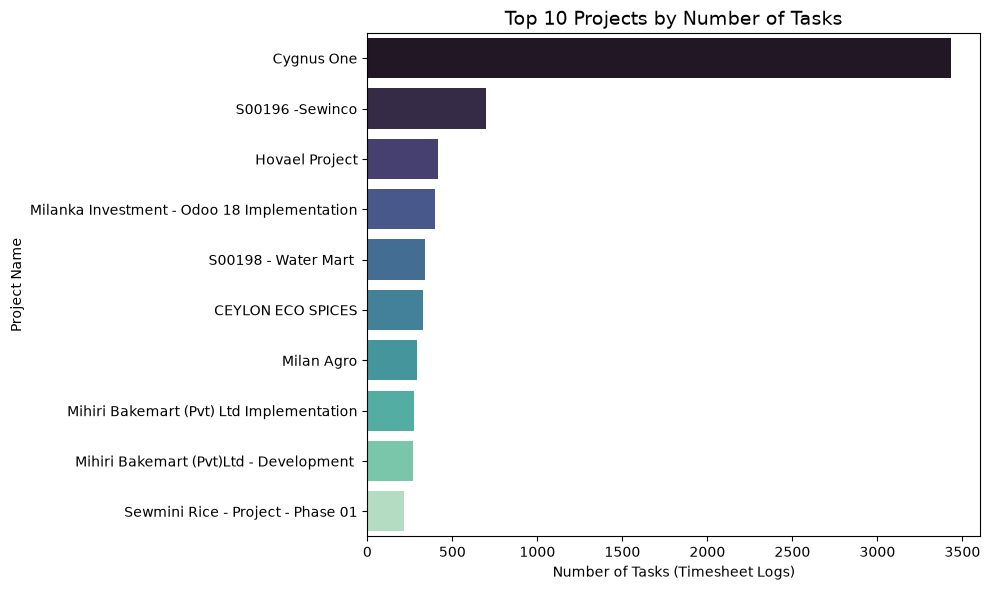

In [79]:
top_projects = df['Project_Name'].value_counts().head(10)
print("\n--- Top 10 Most Common Projects ---")
display(top_projects.to_frame(name='Task Count'))
plt.figure(figsize=(10, 6))
sns.barplot(x=top_projects.values, y=top_projects.index, palette='mako')
plt.title('Top 10 Projects by Number of Tasks', fontsize=14)
plt.xlabel('Number of Tasks (Timesheet Logs)')
plt.ylabel('Project Name')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Tasks_Per_Project.png', dpi=300)
plt.show()


--- Top 10 Employees by Unique Tasks Handled ---


,Unique Tasks Handled
Employee_Name,
W M I L Wijesinghe,260
W A R M Prashansa,223
J A P Swarnamali,221
I G C Bandara,180
L H P S S Pathirana,172
M H R Chandrasoma,166
W M A P Wanninayaka,153
P H M M Mihilanga,149
P E D Fernando,136


/tmp/ipykernel_275556/491998460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_tasks_per_employee.values, y=unique_tasks_per_employee.index, palette='rocket')


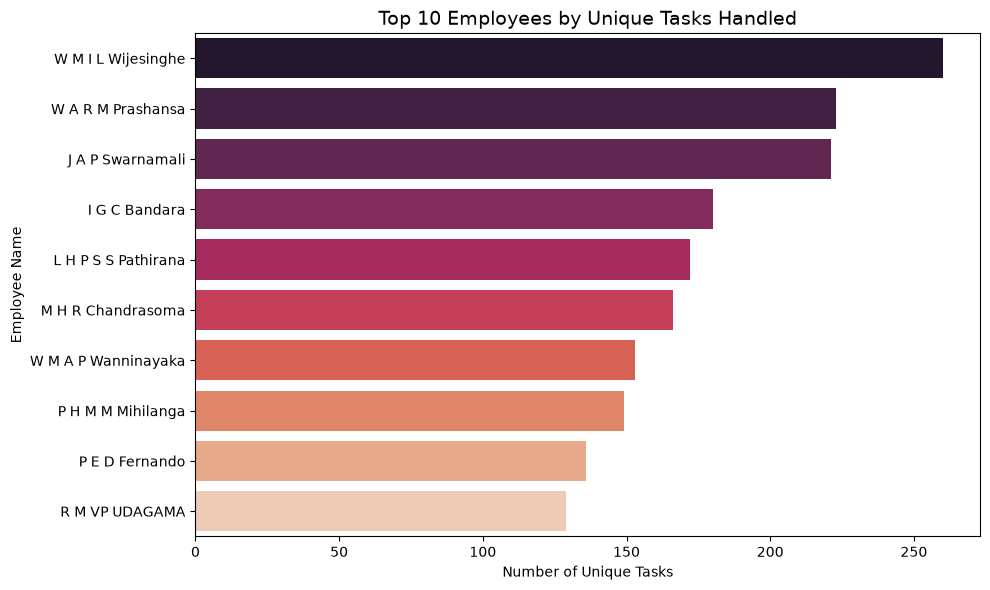

In [80]:
unique_tasks_per_employee = df.groupby('Employee_Name')['Task_ID'].nunique().sort_values(ascending=False).head(10)
print("\n--- Top 10 Employees by Unique Tasks Handled ---")
display(unique_tasks_per_employee.to_frame(name='Unique Tasks Handled'))
plt.figure(figsize=(10, 6))
sns.barplot(x=unique_tasks_per_employee.values, y=unique_tasks_per_employee.index, palette='rocket')
plt.title('Top 10 Employees by Unique Tasks Handled', fontsize=14)
plt.xlabel('Number of Unique Tasks')
plt.ylabel('Employee Name')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Tasks_Across_Employees.png', dpi=300)
plt.show()

---

## Step 5: Time and Effort Analysis

Analyze the time-related variables.

**Focus columns:**
- `Hours_Spent`
- `Estimated_Planned_Hours`
- `Actual_Hours_Spent`
- `Timesheet_Logs_Count`
- `Created_Date`
- `Deadline_Date`
- `Date`

**Tasks in this step:**
- Distribution of hours spent.
- Distribution of planned hours.
- Distribution of actual hours.
- Planned vs actual hours.
- Differences between estimated and actual effort.
- Extremely high or low time values.
- Task duration where date information is available.
- Employee workload based on recorded hours.

**Visualizations:**
- Histograms of time-related variables.
- Boxplots for detecting outliers.
- Planned vs actual hours scatter plot.
- Average hours by employee.
- Average hours by project.

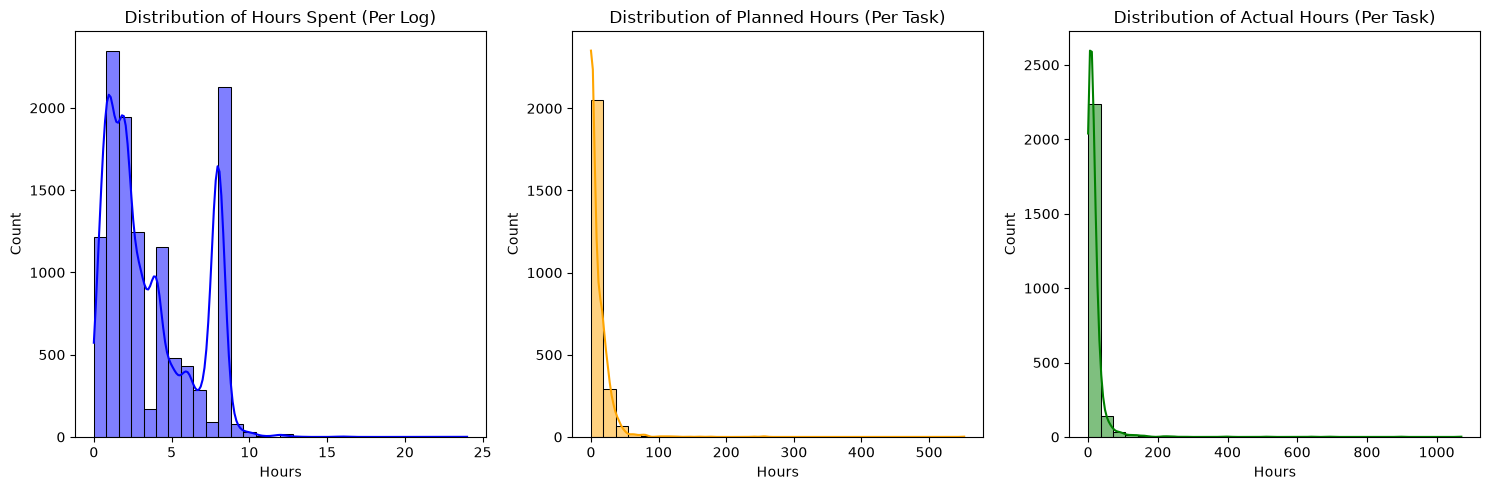

In [81]:
task_level_time = df[['Task_ID', 'Estimated_Planned_Hours', 'Actual_Hours_Spent', 'Timesheet_Logs_Count']].drop_duplicates()
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['Hours_Spent'], bins=30, kde=True, color='blue')
plt.title('Distribution of Hours Spent (Per Log)')
plt.xlabel('Hours')
plt.subplot(1, 3, 2)
sns.histplot(task_level_time['Estimated_Planned_Hours'], bins=30, kde=True, color='orange')
plt.title('Distribution of Planned Hours (Per Task)')
plt.xlabel('Hours')
plt.subplot(1, 3, 3)
sns.histplot(task_level_time['Actual_Hours_Spent'], bins=30, kde=True, color='green')
plt.title('Distribution of Actual Hours (Per Task)')
plt.xlabel('Hours')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Time_Distributions_Histograms.png', dpi=300)
plt.show()

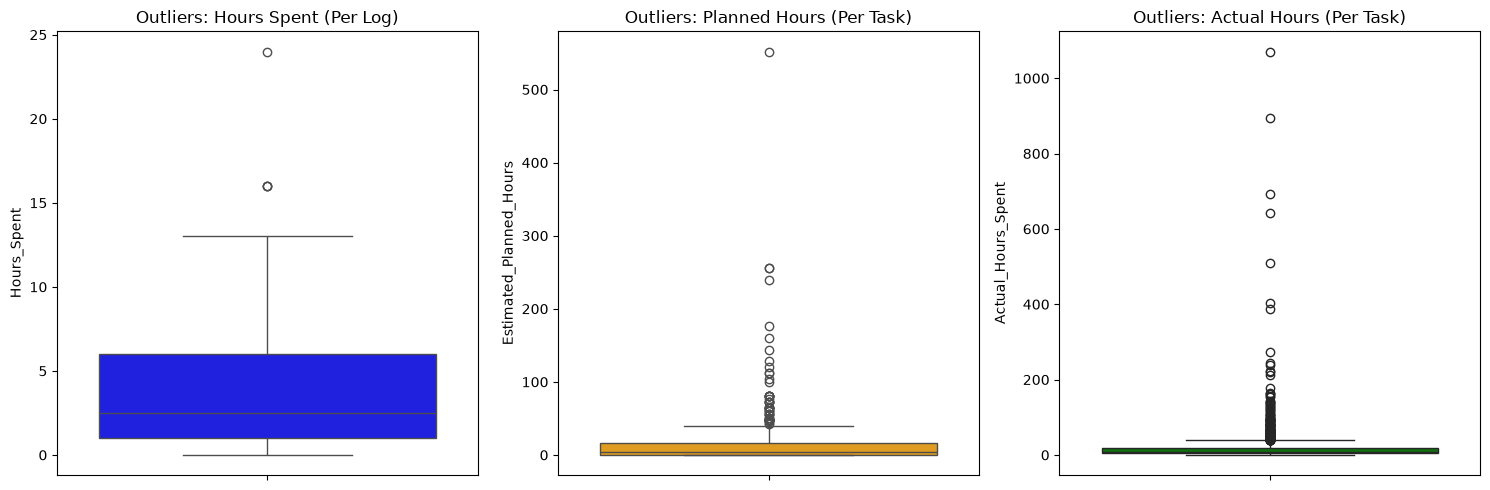

In [82]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Hours_Spent'], color='blue')
plt.title('Outliers: Hours Spent (Per Log)')
plt.subplot(1, 3, 2)
sns.boxplot(y=task_level_time['Estimated_Planned_Hours'], color='orange')
plt.title('Outliers: Planned Hours (Per Task)')
plt.subplot(1, 3, 3)
sns.boxplot(y=task_level_time['Actual_Hours_Spent'], color='green')
plt.title('Outliers: Actual Hours (Per Task)')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Time_Outliers_Boxplots.png', dpi=300)
plt.show()

--- Effort Difference (Actual - Planned) Summary ---


,Difference (Hours)
count,2442.000000
mean,7.556609
std,45.488370
min,-527.500000
25%,-1.000000
50%,1.000000
75%,8.000000
max,1070.870000


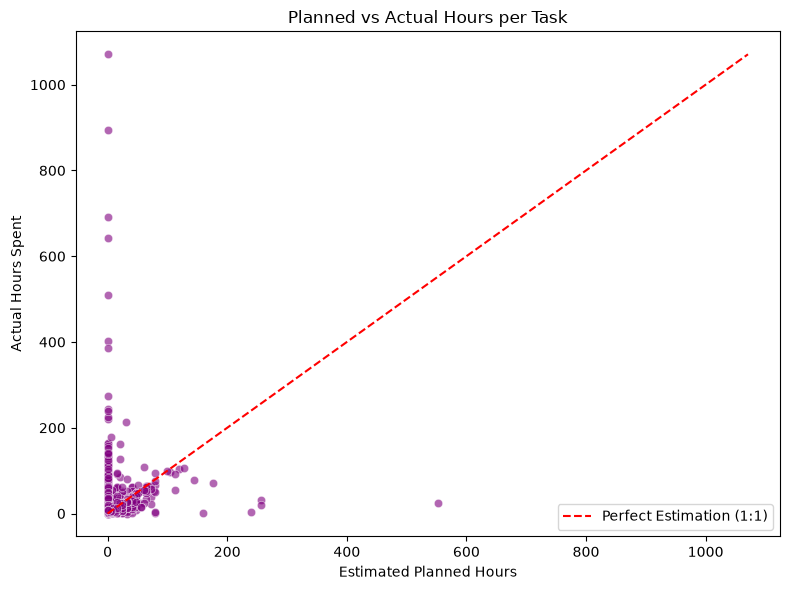

In [83]:
task_level_time['Effort_Difference'] = task_level_time['Actual_Hours_Spent'] - task_level_time['Estimated_Planned_Hours']
print("--- Effort Difference (Actual - Planned) Summary ---")
display(task_level_time['Effort_Difference'].describe().to_frame(name='Difference (Hours)'))
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Estimated_Planned_Hours', 
    y='Actual_Hours_Spent', 
    data=task_level_time, 
    alpha=0.6, 
    color='purple'
)
max_val = max(task_level_time['Estimated_Planned_Hours'].max(), task_level_time['Actual_Hours_Spent'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Estimation (1:1)')
plt.title('Planned vs Actual Hours per Task')
plt.xlabel('Estimated Planned Hours')
plt.ylabel('Actual Hours Spent')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/EDA_Planned_vs_Actual_Scatter.png', dpi=300)
plt.show()

In [84]:
df['Created_Date'] = pd.to_datetime(df['Created_Date'], errors='coerce')
df['Deadline_Date'] = pd.to_datetime(df['Deadline_Date'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
task_dates = df[['Task_ID', 'Created_Date', 'Deadline_Date']].drop_duplicates()
task_dates['Planned_Duration_Days'] = (task_dates['Deadline_Date'] - task_dates['Created_Date']).dt.days
print("\n--- Task Planned Duration (Days) Summary ---")
display(task_dates['Planned_Duration_Days'].dropna().describe().to_frame())


--- Task Planned Duration (Days) Summary ---


,Planned_Duration_Days
count,356.000000
mean,43.879213
std,92.376142
min,-25.000000
25%,0.000000
50%,5.000000
75%,31.500000
max,486.000000


/tmp/ipykernel_275556/4098753898.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_hours_emp.values, y=avg_hours_emp.index, palette='magma')


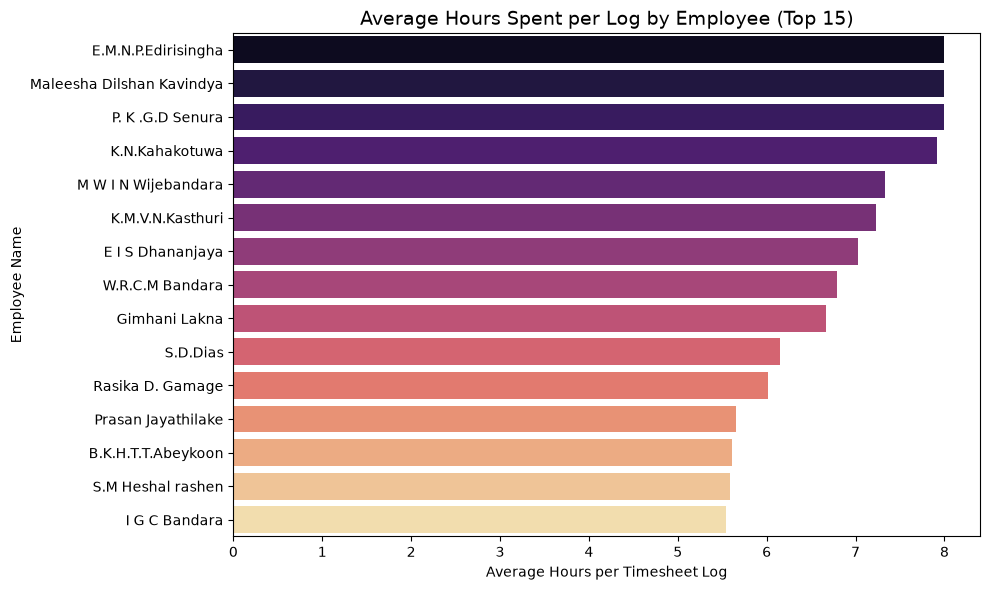

In [85]:
avg_hours_emp = df.groupby('Employee_Name')['Hours_Spent'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_hours_emp.values, y=avg_hours_emp.index, palette='magma')
plt.title('Average Hours Spent per Log by Employee (Top 15)', fontsize=14)
plt.xlabel('Average Hours per Timesheet Log')
plt.ylabel('Employee Name')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Avg_Hours_Employee.png', dpi=300)
plt.show()

/tmp/ipykernel_275556/684031454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_hours_proj.values, y=avg_hours_proj.index, palette='viridis')


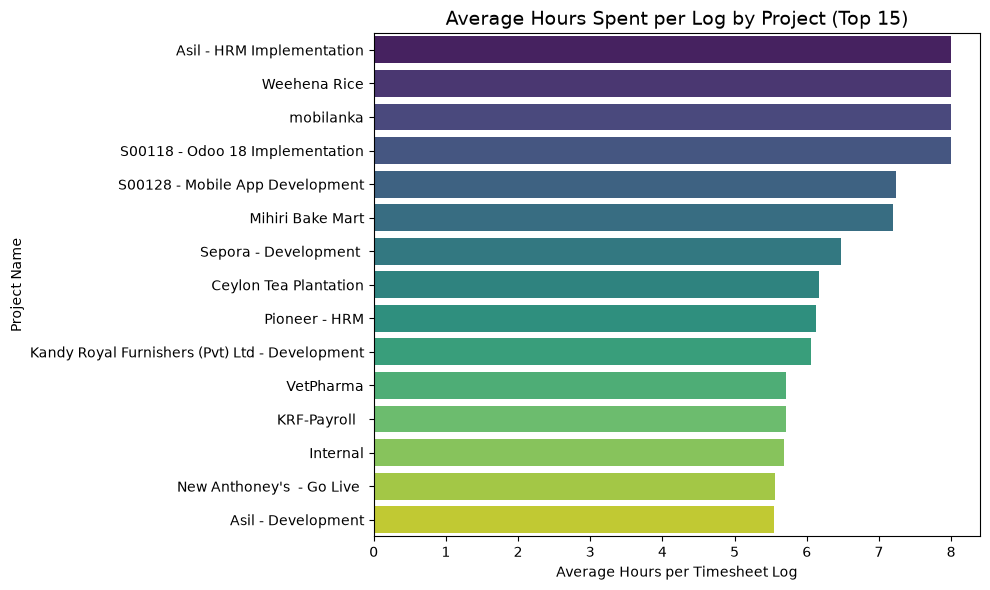

In [86]:
avg_hours_proj = df.groupby('Project_Name')['Hours_Spent'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_hours_proj.values, y=avg_hours_proj.index, palette='viridis')
plt.title('Average Hours Spent per Log by Project (Top 15)', fontsize=14)
plt.xlabel('Average Hours per Timesheet Log')
plt.ylabel('Project Name')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Avg_Hours_Project.png', dpi=300)
plt.show()

---

## Step 6: Project Analysis

Analyze project-level patterns.

**Tasks in this step:**
- Count the number of unique projects.
- Identify projects with the highest number of tasks.
- Identify employees working on each project.
- Analyze department involvement in projects.
- Analyze task distribution across projects.
- Analyze average task hours by project.
- Identify projects with unusually high workloads.

Total Unique Projects: 91

--- Top 15 Projects by Task Logs ---


,Total Tasks/Logs
Project_Name,
Cygnus One,3432
S00196 -Sewinco,700
Hovael Project,416
Milanka Investment - Odoo 18 Implementation,396
S00198 - Water Mart,341
CEYLON ECO SPICES,328
Milan Agro,290
Mihiri Bakemart (Pvt) Ltd Implementation,272
Mihiri Bakemart (Pvt)Ltd - Development,268


/tmp/ipykernel_275556/2108481307.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=project_task_counts.head(20).values, y=project_task_counts.head(20).index, palette='cubehelix')


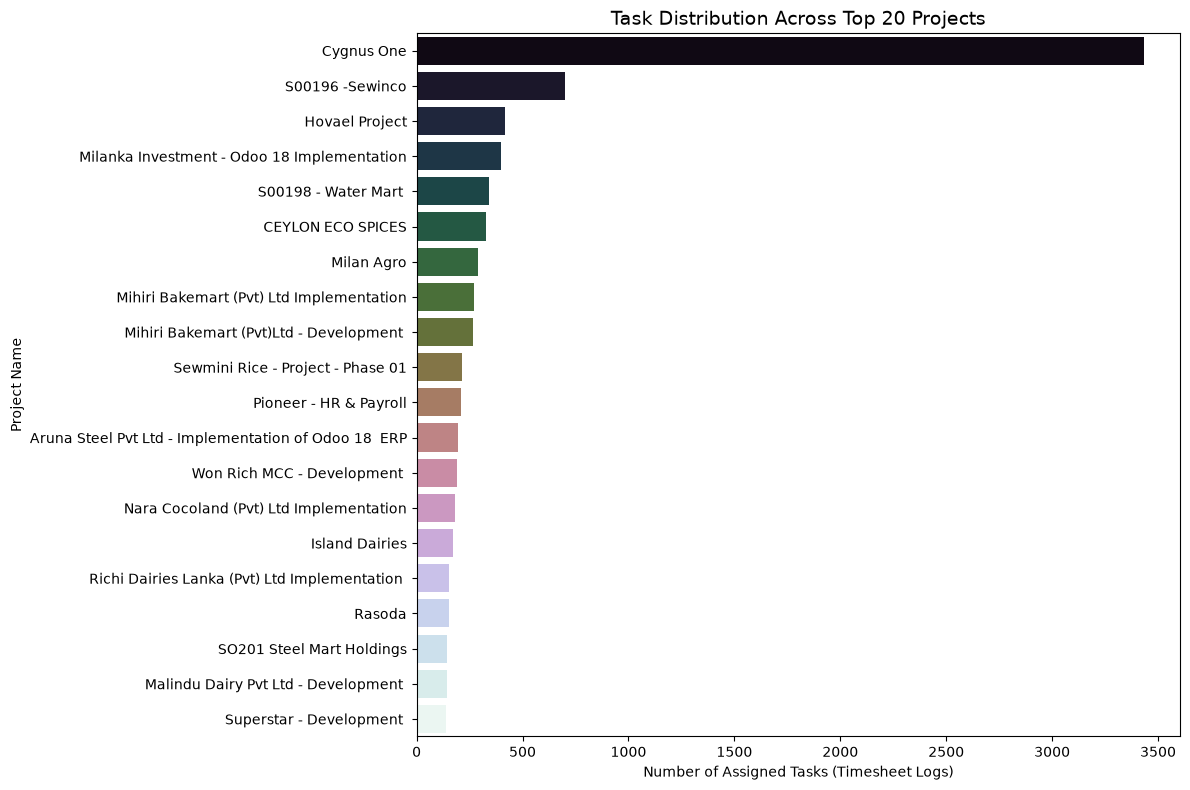

In [87]:
unique_projects = df['Project_Name'].nunique()
print(f"Total Unique Projects: {unique_projects}\n")
project_task_counts = df['Project_Name'].value_counts()
print("--- Top 15 Projects by Task Logs ---")
display(project_task_counts.head(15).to_frame(name='Total Tasks/Logs'))
plt.figure(figsize=(12, 8))
sns.barplot(x=project_task_counts.head(20).values, y=project_task_counts.head(20).index, palette='cubehelix')
plt.title('Task Distribution Across Top 20 Projects', fontsize=14)
plt.xlabel('Number of Assigned Tasks (Timesheet Logs)')
plt.ylabel('Project Name')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Project_Task_Distribution.png', dpi=300)
plt.show()


--- Employee and Department Involvement per Project (Top 15) ---


,Unique_Employees,Unique_Departments
Project_Name,,
Cygnus One,46,7
Internal,29,6
S00198 - Water Mart,19,3
Hovael Project,18,3
Milan Agro,18,3
Sewmini Rice - Project - Phase 01,18,4
S00196 -Sewinco,18,5
CEYLON ECO SPICES,17,4
Mihiri Bakemart (Pvt)Ltd - Development,16,2


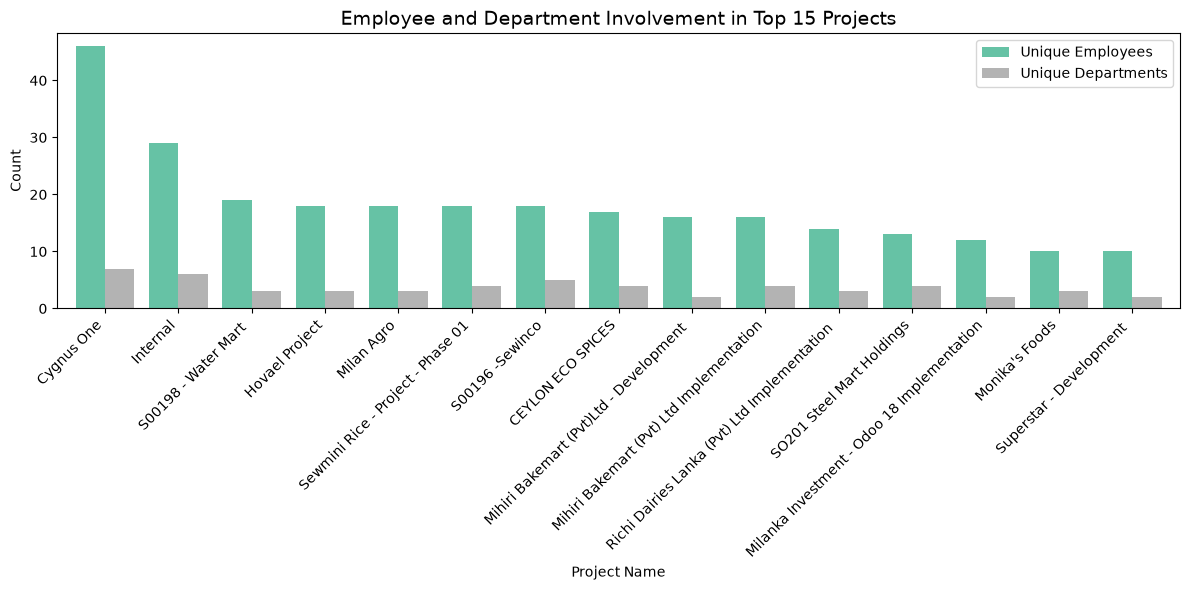

In [88]:
project_involvement = df.groupby('Project_Name').agg({
    'Employee_Name': 'nunique',
    'Employee_Department': 'nunique'
}).rename(columns={'Employee_Name': 'Unique_Employees', 'Employee_Department': 'Unique_Departments'})
project_involvement = project_involvement.sort_values(by='Unique_Employees', ascending=False)
print("\n--- Employee and Department Involvement per Project (Top 15) ---")
display(project_involvement.head(15))
fig, ax = plt.subplots(figsize=(12, 6))
project_involvement.head(15).plot(kind='bar', ax=ax, colormap='Set2', width=0.8)
plt.title('Employee and Department Involvement in Top 15 Projects', fontsize=14)
plt.ylabel('Count')
plt.xlabel('Project Name')
plt.xticks(rotation=45, ha='right')
plt.legend(['Unique Employees', 'Unique Departments'])
plt.tight_layout()
plt.savefig('../results/figures/EDA_Project_Involvement.png', dpi=300)
plt.show()


--- Project Workload Analysis (Top 15 by Total Hours) ---


,Total_Hours_Spent,Average_Hours_Per_Log
Project_Name,,
Cygnus One,9387.39,2.735253
S00196 -Sewinco,2898.50,4.140714
Hovael Project,2158.91,5.189687
Milan Agro,1415.42,4.880759
S00198 - Water Mart,1314.42,3.854604
Mihiri Bakemart (Pvt)Ltd - Development,1180.92,4.406418
Milanka Investment - Odoo 18 Implementation,1157.08,2.921919
Mihiri Bakemart (Pvt) Ltd Implementation,1107.84,4.072941
CEYLON ECO SPICES,915.50,2.791159


/tmp/ipykernel_275556/3047611355.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


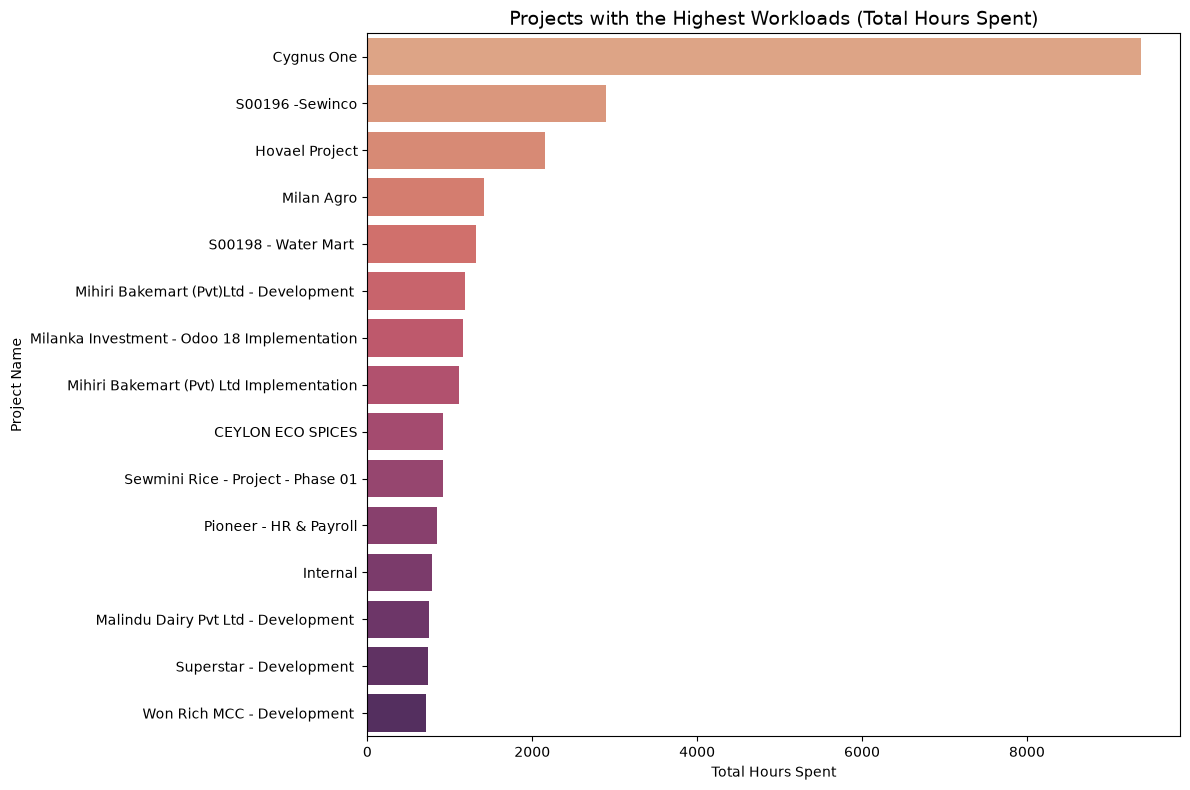

In [89]:
project_workload = df.groupby('Project_Name').agg({
    'Hours_Spent': ['sum', 'mean']
})
project_workload.columns = ['Total_Hours_Spent', 'Average_Hours_Per_Log']
project_workload = project_workload.sort_values(by='Total_Hours_Spent', ascending=False)
print("\n--- Project Workload Analysis (Top 15 by Total Hours) ---")
display(project_workload.head(15))
plt.figure(figsize=(12, 8))
sns.barplot(
    x=project_workload['Total_Hours_Spent'].head(15).values, 
    y=project_workload.head(15).index, 
    palette='flare'
)
plt.title('Projects with the Highest Workloads (Total Hours Spent)', fontsize=14)
plt.xlabel('Total Hours Spent')
plt.ylabel('Project Name')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Project_Total_Workload.png', dpi=300)
plt.show()

---

## Step 7: Employee–Task Relationship Analysis

This is one of the most important parts of the EDA because the final system will **recommend employees for tasks**.

**Investigate:**
- Which employees perform which types of tasks.
- Which employees work on which projects.
- Employee–project relationships.
- Employee–task relationships.
- Employee–department relationships.
- Employee–job-position relationships.
- Frequency of employees being assigned to particular task types.
- Previous employee experience with similar tasks/projects.

Analyze whether historical employee-task assignments show **meaningful patterns** that could help predict suitable employees for future tasks.

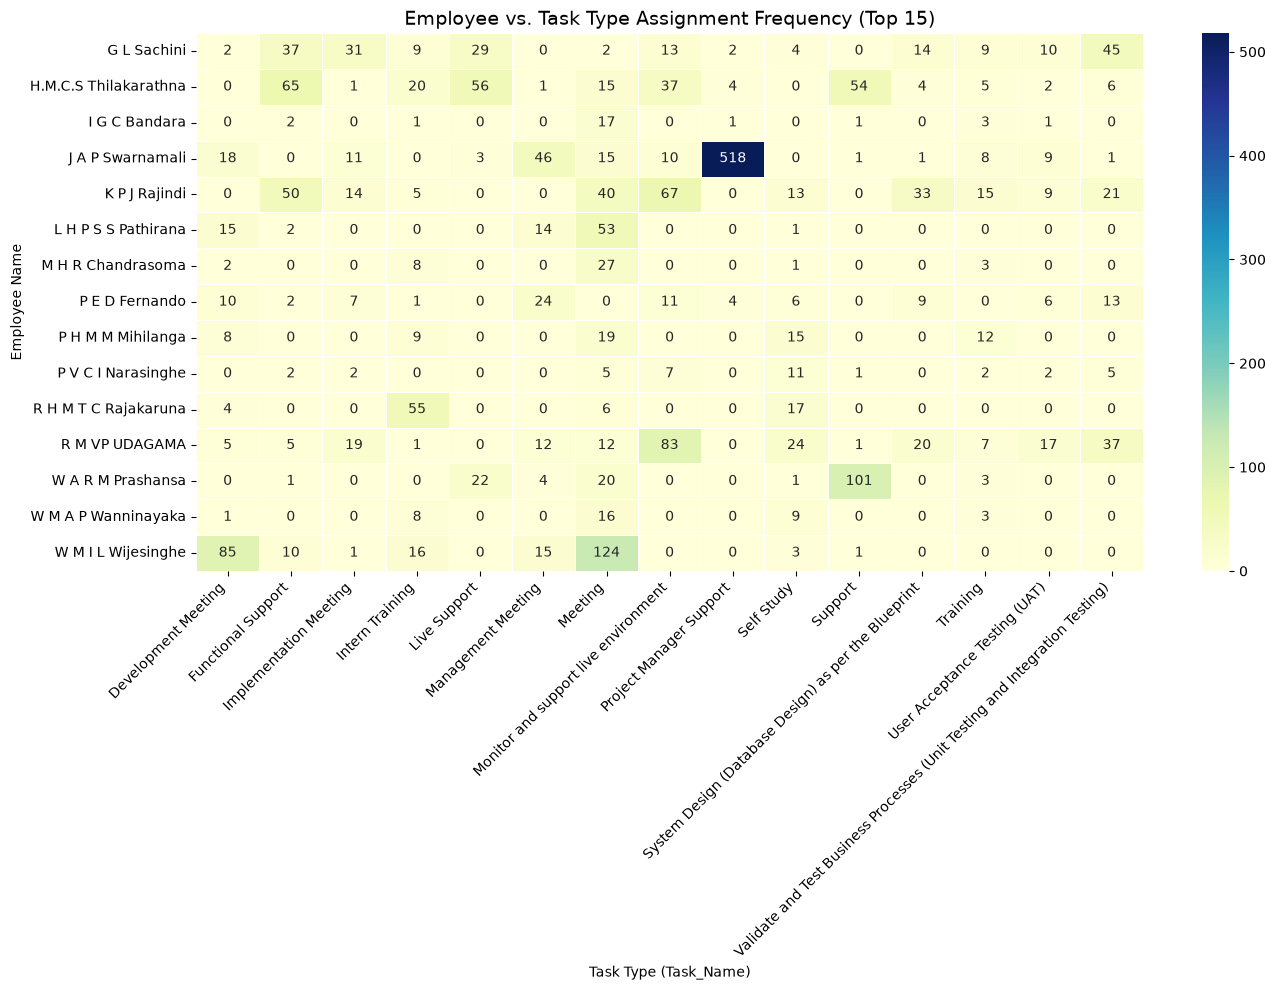

In [90]:
top_emps = df['Employee_Name'].value_counts().head(15).index
top_task_types = df['Task_Name'].value_counts().head(15).index
filtered_df_tasks = df[df['Employee_Name'].isin(top_emps) & df['Task_Name'].isin(top_task_types)]
emp_task_crosstab = pd.crosstab(filtered_df_tasks['Employee_Name'], filtered_df_tasks['Task_Name'])
plt.figure(figsize=(14, 10))
sns.heatmap(emp_task_crosstab, cmap="YlGnBu", annot=True, fmt="d", linewidths=.5)
plt.title('Employee vs. Task Type Assignment Frequency (Top 15)', fontsize=14)
plt.xlabel('Task Type (Task_Name)')
plt.ylabel('Employee Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Employee_Task_Relationship.png', dpi=300)
plt.show()

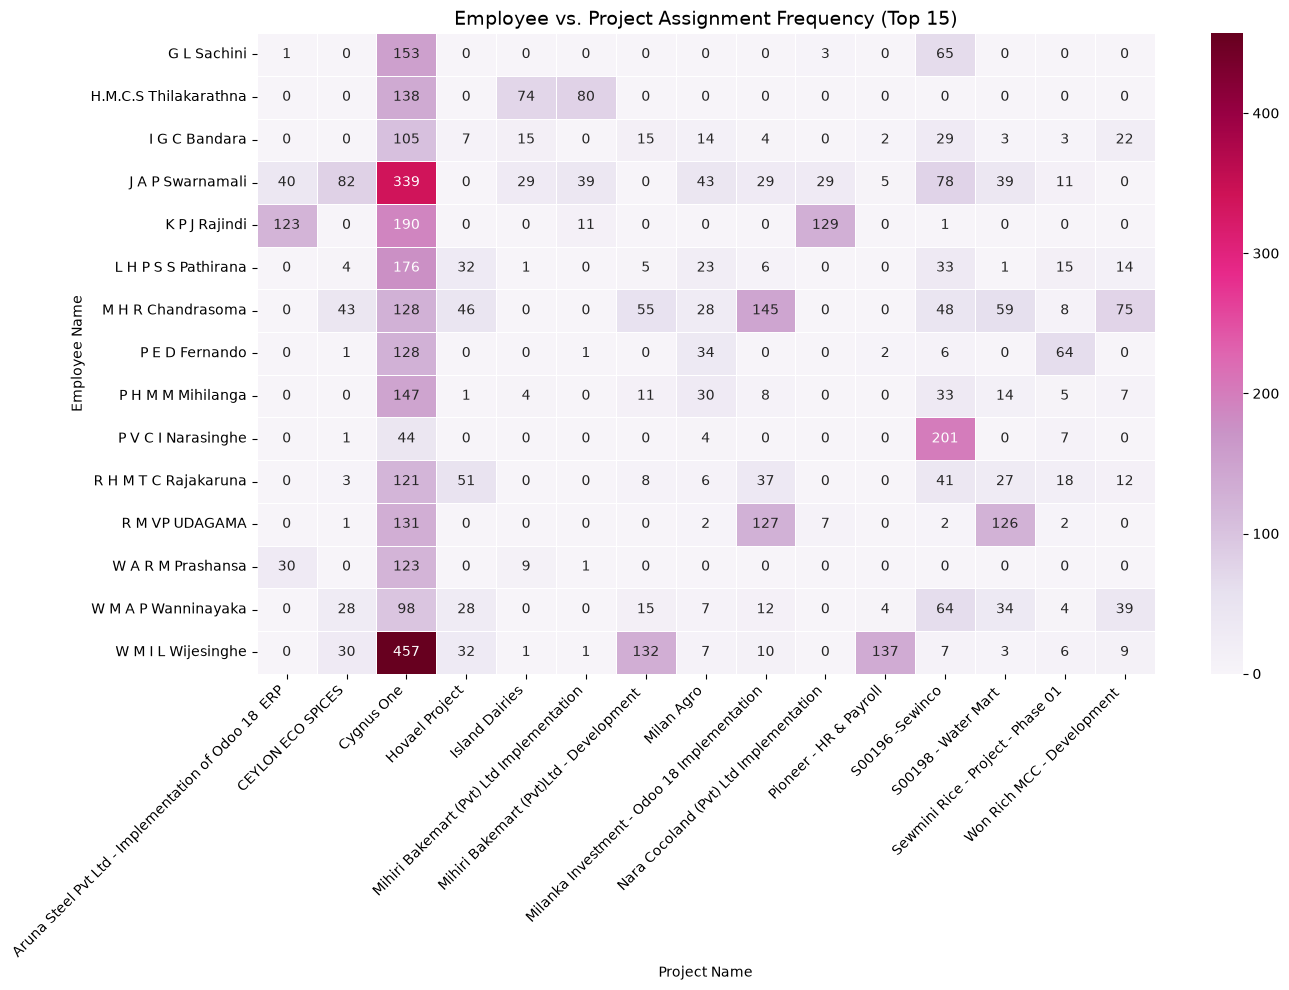

In [91]:
top_projects_rel = df['Project_Name'].value_counts().head(15).index
filtered_df_projs = df[df['Employee_Name'].isin(top_emps) & df['Project_Name'].isin(top_projects_rel)]
emp_proj_crosstab = pd.crosstab(filtered_df_projs['Employee_Name'], filtered_df_projs['Project_Name'])
plt.figure(figsize=(14, 10))
sns.heatmap(emp_proj_crosstab, cmap="PuRd", annot=True, fmt="d", linewidths=.5)
plt.title('Employee vs. Project Assignment Frequency (Top 15)', fontsize=14)
plt.xlabel('Project Name')
plt.ylabel('Employee Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Employee_Project_Relationship.png', dpi=300)
plt.show()

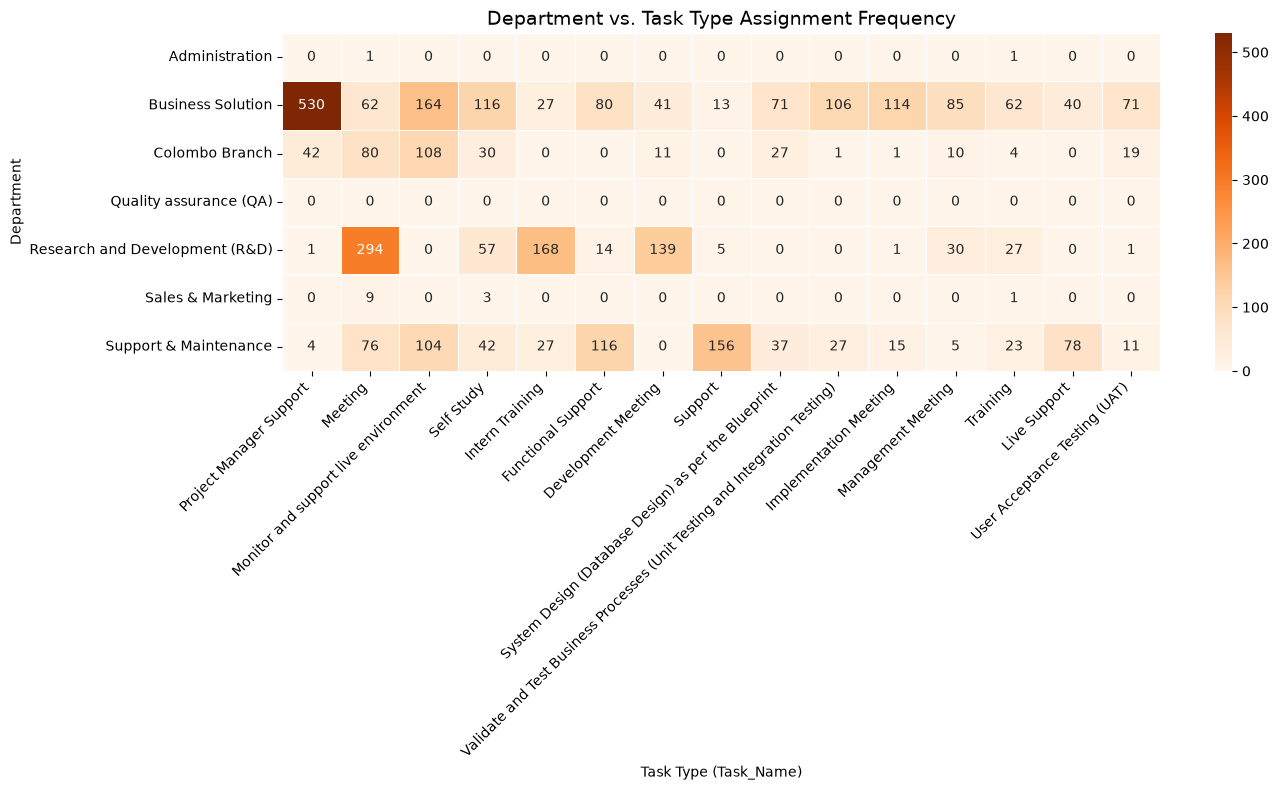

In [92]:
dept_task_crosstab = pd.crosstab(df['Employee_Department'], df['Task_Name'])
dept_task_crosstab = dept_task_crosstab[top_task_types]
plt.figure(figsize=(14, 8))
sns.heatmap(dept_task_crosstab, cmap="Oranges", annot=True, fmt="d", linewidths=.5)
plt.title('Department vs. Task Type Assignment Frequency', fontsize=14)
plt.xlabel('Task Type (Task_Name)')
plt.ylabel('Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Department_Task_Relationship.png', dpi=300)
plt.show()

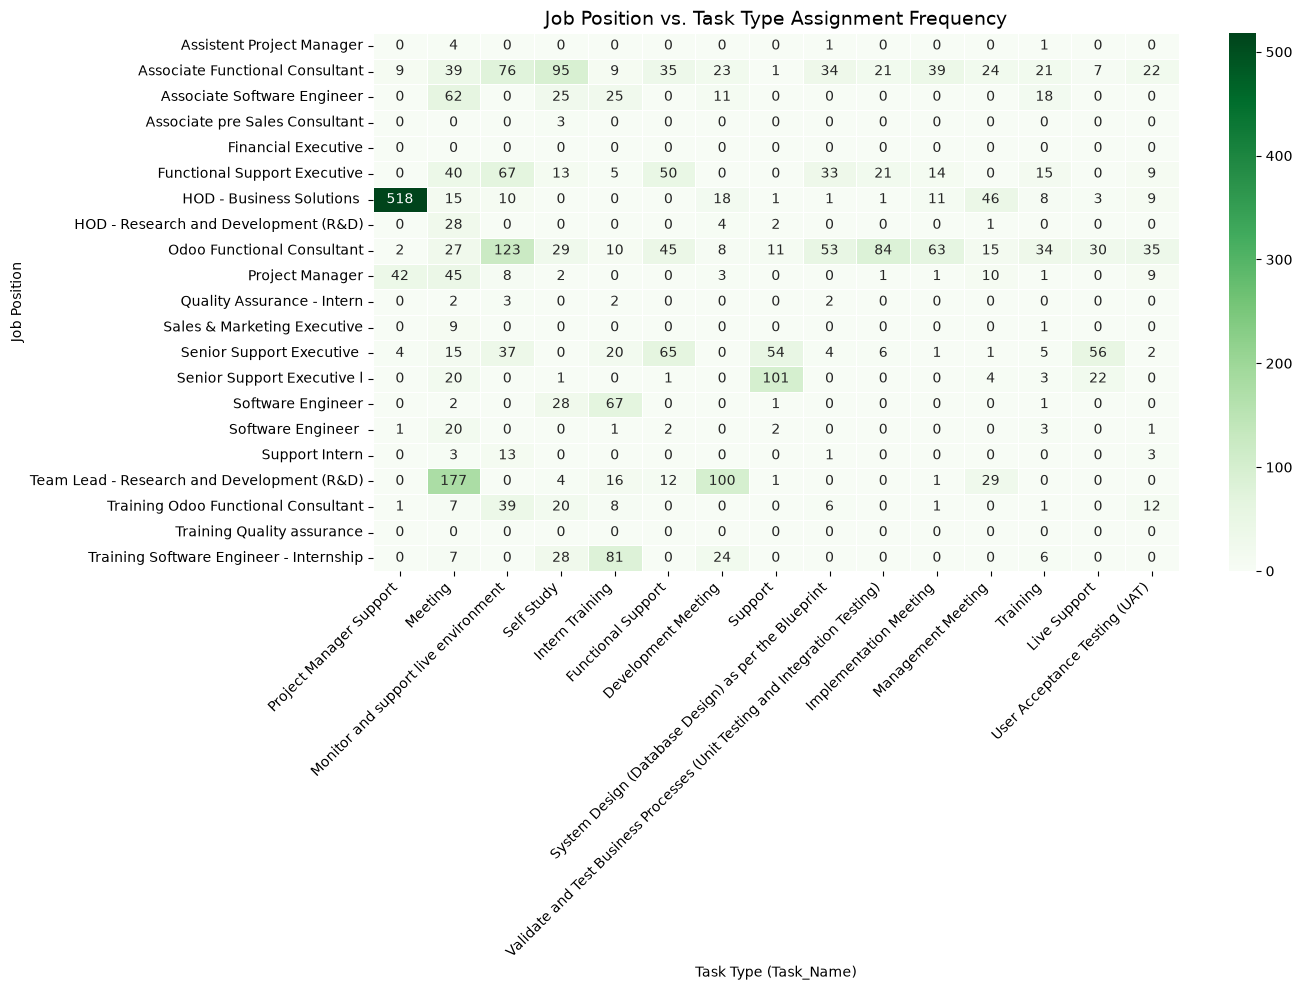

In [93]:
job_task_crosstab = pd.crosstab(df['Employee_Job_Position'], df['Task_Name'])
job_task_crosstab = job_task_crosstab[top_task_types]
plt.figure(figsize=(14, 10))
sns.heatmap(job_task_crosstab, cmap="Greens", annot=True, fmt="d", linewidths=.5)
plt.title('Job Position vs. Task Type Assignment Frequency', fontsize=14)
plt.xlabel('Task Type (Task_Name)')
plt.ylabel('Job Position')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/EDA_JobPosition_Task_Relationship.png', dpi=300)
plt.show()

--- Top 15 Employee-Task Combinations by Total Effort (Domain Experts) ---


,Employee_Name,Task_Name,Hours_Spent
771,J A P Swarnamali,Project Manager Support,875.33
158,E I S Dhananjaya,systems co-ordination,379.00
2467,W A R M Prashansa,Support,315.83
2943,W.R.C.M Bandara,Implement a support plan,307.80
2037,R M VP UDAGAMA,Monitor and support live environment,255.00
2486,W A R M Prashansa,Upload backups,230.21
2944,W.R.C.M Bandara,Implement and support,192.00
2822,W M I L Wijesinghe,Meeting,177.16
165,E.M.N.P.Edirisingha,Intern Training,176.00
1914,R H M T C Rajakaruna,Intern Training,164.50


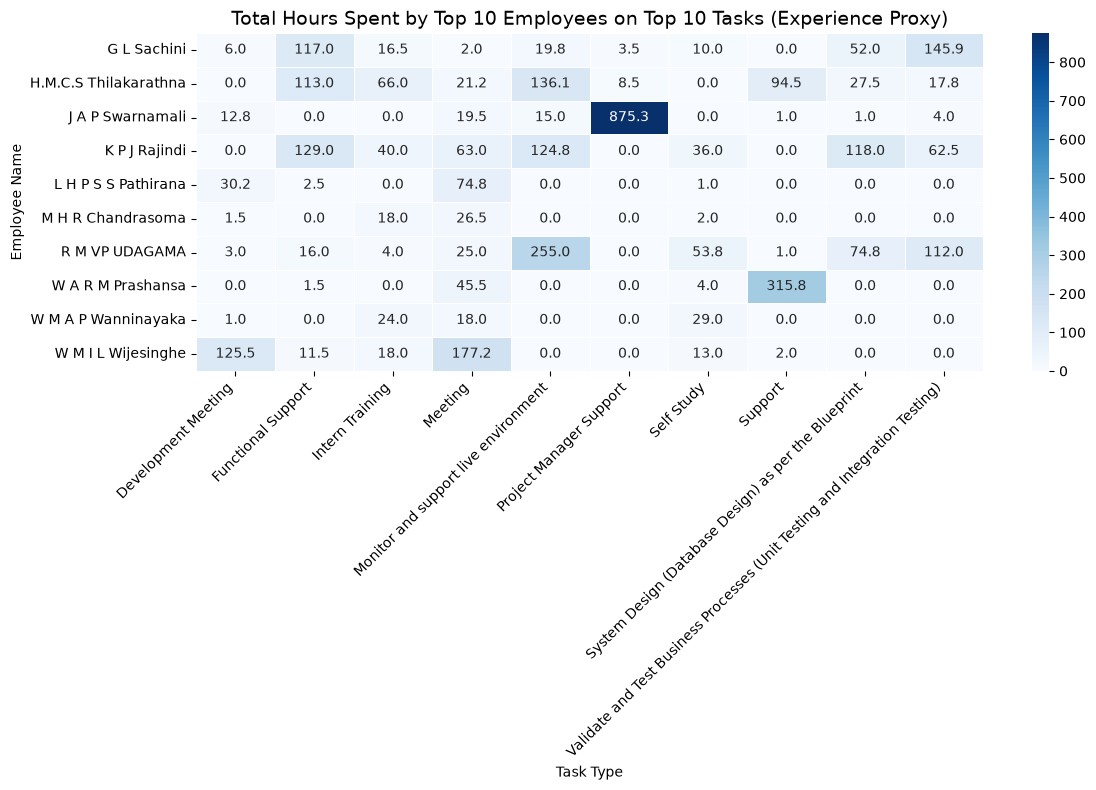

In [94]:
emp_experience = df.groupby(['Employee_Name', 'Task_Name'])['Hours_Spent'].sum().reset_index()
emp_experience = emp_experience.sort_values(by='Hours_Spent', ascending=False)
print("--- Top 15 Employee-Task Combinations by Total Effort (Domain Experts) ---")
display(emp_experience.head(15))
top_exp_pivot = emp_experience[emp_experience['Employee_Name'].isin(top_emps[:10]) & 
                               emp_experience['Task_Name'].isin(top_task_types[:10])]
top_exp_pivot = top_exp_pivot.pivot(index='Employee_Name', columns='Task_Name', values='Hours_Spent').fillna(0)
plt.figure(figsize=(12, 8))
sns.heatmap(top_exp_pivot, cmap="Blues", annot=True, fmt=".1f", linewidths=.5)
plt.title('Total Hours Spent by Top 10 Employees on Top 10 Tasks (Experience Proxy)', fontsize=14)
plt.xlabel('Task Type')
plt.ylabel('Employee Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Employee_Experience_Heatmap.png', dpi=300)
plt.show()

---

## Step 8: Text Data Analysis

Since the dataset contains task-related text, analyze:

- `Task_Name`
- `Work_Description`
- `Task_Description`
- `Original_Task_Description`
- `Timesheet_Work_Logs`

**Perform basic NLP-oriented EDA:**
- Missing text values.
- Text length distribution.
- Average number of words per description.
- Most frequent words.
- Common task-related keywords.
- Similarity between task title and description fields.
- Identify whether different columns contain duplicate or highly similar information.

**Visualizations:**
- Text-length distributions.
- Most frequent keywords.
- Word-frequency plots.

In [95]:
text_cols = [
    'Task_Name', 'Work_Description', 'Task_Description', 
    'Original_Task_Description', 'Timesheet_Work_Logs'
]
text_cols = [col for col in text_cols if col in df.columns]
print("--- Missing Values in Text Columns ---")
display(df[text_cols].isnull().sum().to_frame(name='Missing Count'))

--- Missing Values in Text Columns ---


,Missing Count
Task_Name,0
Work_Description,1
Task_Description,0
Original_Task_Description,11565
Timesheet_Work_Logs,74



--- Average Word Count per Column ---
Task_Name: 3.5 words on average
Work_Description: 6.6 words on average
Task_Description: 315.7 words on average
Original_Task_Description: 11.1 words on average
Timesheet_Work_Logs: 312.2 words on average


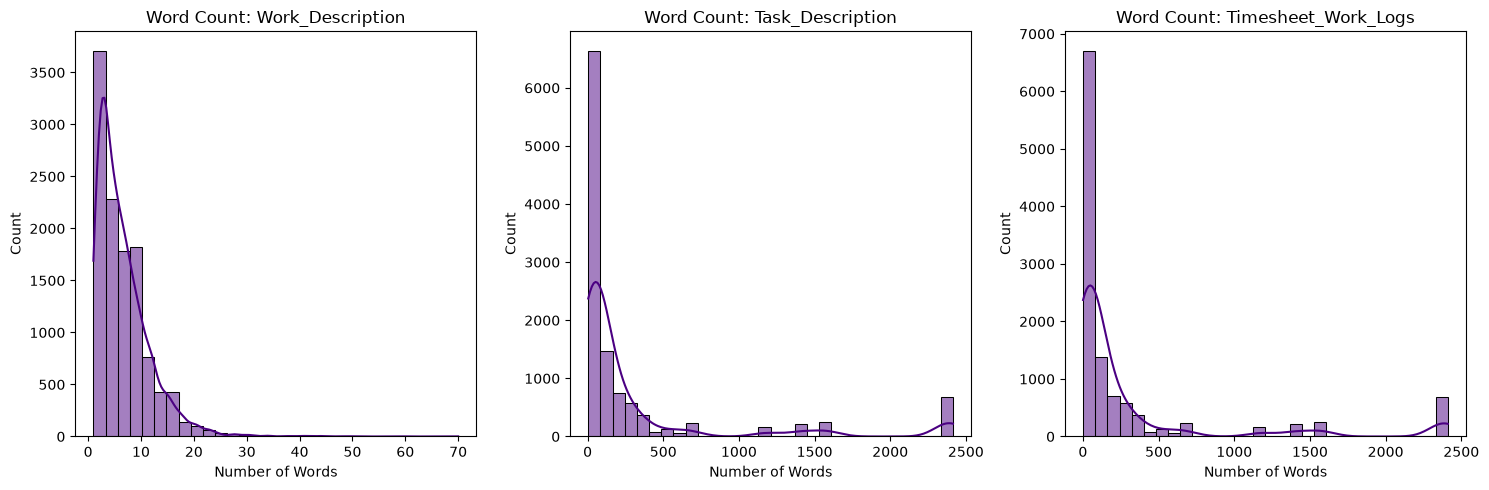

In [96]:
print("\n--- Average Word Count per Column ---")
for col in text_cols:
    df[f'{col}_WordCount'] = df[col].dropna().astype(str).apply(lambda x: len(x.split()))
    avg_words = df[f'{col}_WordCount'].mean()
    print(f"{col}: {avg_words:.1f} words on average")
plt.figure(figsize=(15, 5))
plot_cols = [c for c in ['Work_Description', 'Task_Description', 'Timesheet_Work_Logs'] if c in df.columns]
for i, col in enumerate(plot_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[f'{col}_WordCount'].dropna(), bins=30, kde=True, color='indigo')
    plt.title(f'Word Count: {col}', fontsize=12)
    plt.xlabel('Number of Words')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Text_Length_Distributions.png', dpi=300)
plt.show()


--- Top 15 Keywords in Work_Description ---


,Keyword,Frequency
0,meeting,1218
1,development,922
2,report,787
3,support,747
4,create,597
5,new,560
6,issue,495
7,addon,490
8,database,476
9,setup,454


/tmp/ipykernel_275556/2687524470.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Keyword', data=top_wd_df, palette='rocket')


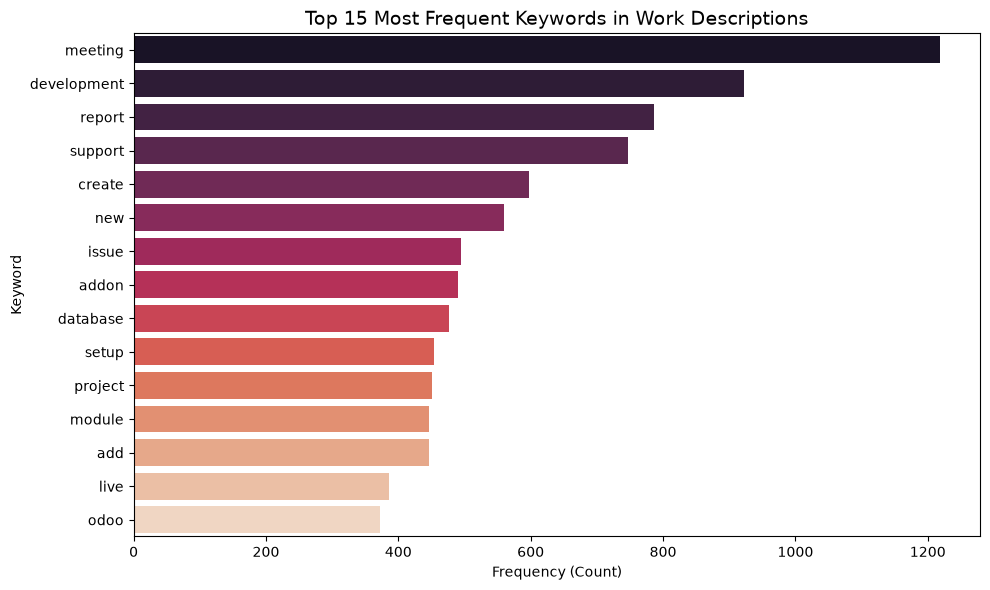

In [97]:
def get_top_keywords(series, n=20):
    """Extracts top words, filtering out basic stop words and short text."""
    text = " ".join(series.dropna().astype(str).str.lower().tolist())
    words = re.findall(r'\b[a-z]{3,}\b', text)
    stop_words = {
        'the', 'and', 'for', 'with', 'this', 'that', 'not', 'are', 'was', 'from', 
        'have', 'has', 'task', 'work', 'done', 'details', 'update', 'test'
    }
    words = [w for w in words if w not in stop_words]
    return Counter(words).most_common(n)
top_work_desc = get_top_keywords(df['Work_Description'], 15)
top_wd_df = pd.DataFrame(top_work_desc, columns=['Keyword', 'Frequency'])
print("\n--- Top 15 Keywords in Work_Description ---")
display(top_wd_df)
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Keyword', data=top_wd_df, palette='rocket')
plt.title('Top 15 Most Frequent Keywords in Work Descriptions', fontsize=14)
plt.xlabel('Frequency (Count)')
plt.ylabel('Keyword')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Top_Keywords_WorkDesc.png', dpi=300)
plt.show()

In [98]:
if 'Task_Name' in df.columns and 'Task_Description' in df.columns:
    def check_name_in_desc(row):
        if pd.isna(row['Task_Name']) or pd.isna(row['Task_Description']):
            return False
        return str(row['Task_Name']).lower() in str(row['Task_Description']).lower()
    df['Name_in_Description'] = df.apply(check_name_in_desc, axis=1)
    overlap_pct = df['Name_in_Description'].mean() * 100
    print(f"\n--- Field Similarity Check ---")
    print(f"Task_Name is explicitly contained within the Task_Description in {overlap_pct:.1f}% of records.")
    print("Note: 'Task_Title' was actively dropped during Data Preparation because it was an exact duplicate of 'Task_Name'.")
    print("Conclusion: 'Task_Description' acts as a superset of 'Task_Name', containing both the title and extended NLP context.")


--- Field Similarity Check ---
Task_Name is explicitly contained within the Task_Description in 100.0% of records.
Note: 'Task_Title' was actively dropped during Data Preparation because it was an exact duplicate of 'Task_Name'.
Conclusion: 'Task_Description' acts as a superset of 'Task_Name', containing both the title and extended NLP context.


---

## Step 9: Target Variable Analysis

Investigate the proposed target variable: **`Employee_ID`** (the employee assigned to the task).

**Tasks in this step:**
- Number of unique employees/classes.
- Number of tasks assigned to each employee.
- Target-class distribution.
- Most frequently assigned employees.
- Least frequently assigned employees.
- Percentage of assignments represented by the top employees.
- Whether the target distribution is highly imbalanced.

> ⚠️ **This step is critical** because the project aims to recommend employees for new tasks. We need to determine whether there are enough historical examples for each employee to support reliable model training.

In [99]:
target_col = 'Employee_ID'
label_col = 'Employee_Name'
num_classes = df[target_col].nunique()
print(f"Total Unique Classes (Employees) for Target Variable: {num_classes}\n")

Total Unique Classes (Employees) for Target Variable: 49



In [100]:
class_distribution = df[label_col].value_counts().reset_index()
class_distribution.columns = ['Employee_Name', 'Task_Count']
class_distribution['Percentage (%)'] = (class_distribution['Task_Count'] / len(df)) * 100
class_distribution['Cumulative_Percentage (%)'] = class_distribution['Percentage (%)'].cumsum()
print("--- Most Frequently Assigned Employees (Top 5 Classes) ---")
display(class_distribution.head(5))
print("\n--- Least Frequently Assigned Employees (Bottom 5 Classes) ---")
display(class_distribution.tail(5))

--- Most Frequently Assigned Employees (Top 5 Classes) ---


,Employee_Name,Task_Count,Percentage (%),Cumulative_Percentage (%)
0,J A P Swarnamali,1010,8.682197,8.682197
1,M H R Chandrasoma,959,8.243789,16.925986
2,W M I L Wijesinghe,946,8.132038,25.058025
3,G L Sachini,604,5.192126,30.250150
4,H.M.C.S Thilakarathna,547,4.702140,34.952291



--- Least Frequently Assigned Employees (Bottom 5 Classes) ---


,Employee_Name,Task_Count,Percentage (%),Cumulative_Percentage (%)
44,S.D.Dias,13,0.111751,99.836672
45,H D A M Jayasinghe,9,0.077366,99.914038
46,Gimhani Lakna,6,0.051577,99.965615
47,Maleesha Dilshan Kavindya,2,0.017192,99.982808
48,Administrator,2,0.017192,100.000000


In [101]:
top_20_percent_count = max(1, int(num_classes * 0.2))
top_20_share = class_distribution.loc[top_20_percent_count - 1, 'Cumulative_Percentage (%)']
print(f"\n--- Target Distribution & Class Imbalance ---")
print(f"The top 20% of employees ({top_20_percent_count} individuals) account for {top_20_share:.1f}% of all historical task assignments.")


--- Target Distribution & Class Imbalance ---
The top 20% of employees (9 individuals) account for 52.6% of all historical task assignments.


In [102]:
low_sample_threshold = 50
underrepresented_emps = class_distribution[class_distribution['Task_Count'] < low_sample_threshold]
print(f"\nModel Reliability Warning:")
print(f"{len(underrepresented_emps)} out of {num_classes} employees have fewer than {low_sample_threshold} historical task records.")
if len(underrepresented_emps) > (num_classes * 0.3):
    print("Conclusion: The target variable is highly imbalanced. The long tail of employees with very few assigned tasks will make reliable model training difficult for those specific classes. You will likely need to employ class weighting, SMOTE, or group rare employees into an 'Other' category during the preprocessing phase.")


Model Reliability Warning:
11 out of 49 employees have fewer than 50 historical task records.


/tmp/ipykernel_275556/2934505067.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



Target class distribution plot saved to: ../results/figures/EDA_Target_Class_Imbalance.png


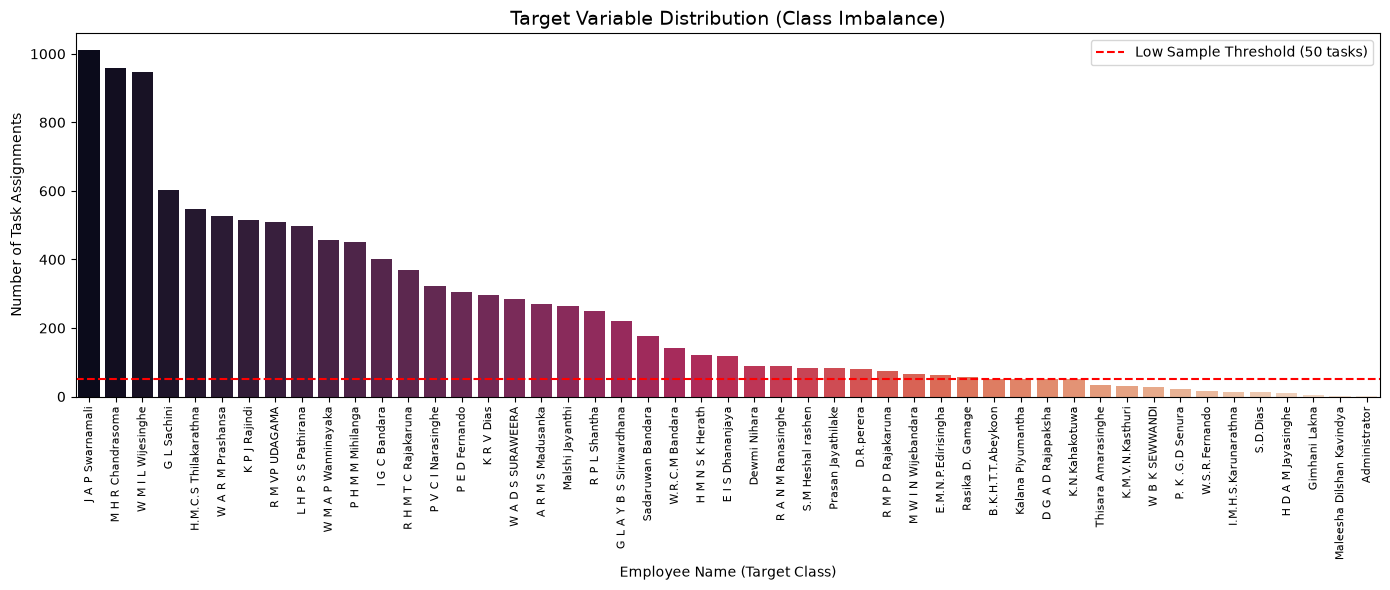

In [103]:
plt.figure(figsize=(14, 6))
sns.barplot(
    x='Employee_Name', 
    y='Task_Count', 
    data=class_distribution,
    palette='rocket'
)
plt.title('Target Variable Distribution (Class Imbalance)', fontsize=14)
plt.xlabel('Employee Name (Target Class)')
plt.ylabel('Number of Task Assignments')
plt.xticks(rotation=90, fontsize=8)
plt.axhline(
    y=low_sample_threshold, 
    color='red', 
    linestyle='--', 
    label=f'Low Sample Threshold ({low_sample_threshold} tasks)'
)
plt.legend()
plt.tight_layout()
save_path_target = '../results/figures/EDA_Target_Class_Imbalance.png'
plt.savefig(save_path_target, dpi=300)
print(f"\nTarget class distribution plot saved to: {save_path_target}")
plt.show()

---

## Step 10: Correlation and Relationship Analysis

Analyze relationships between important numerical and categorical variables.

**Relationships to investigate:**
- Estimated hours vs actual hours.
- Hours spent vs task stage.
- Hours spent vs priority.
- Task assignments vs department.
- Task assignments vs job position.
- Employee vs project.
- Employee vs task type.
- Project vs task priority.

**Visualizations:**
- Correlation heatmap for numerical variables.
- Grouped bar charts.
- Boxplots.
- Scatter plots.
- Cross-tabulations.

--- Numerical Correlation Matrix ---


,Hours_Spent,Estimated_Planned_Hours,Actual_Hours_Spent,Timesheet_Logs_Count
Hours_Spent,1.000000,0.188349,-0.048281,-0.186024
Estimated_Planned_Hours,0.188349,1.000000,-0.151408,-0.164427
Actual_Hours_Spent,-0.048281,-0.151408,1.000000,0.868977
Timesheet_Logs_Count,-0.186024,-0.164427,0.868977,1.000000


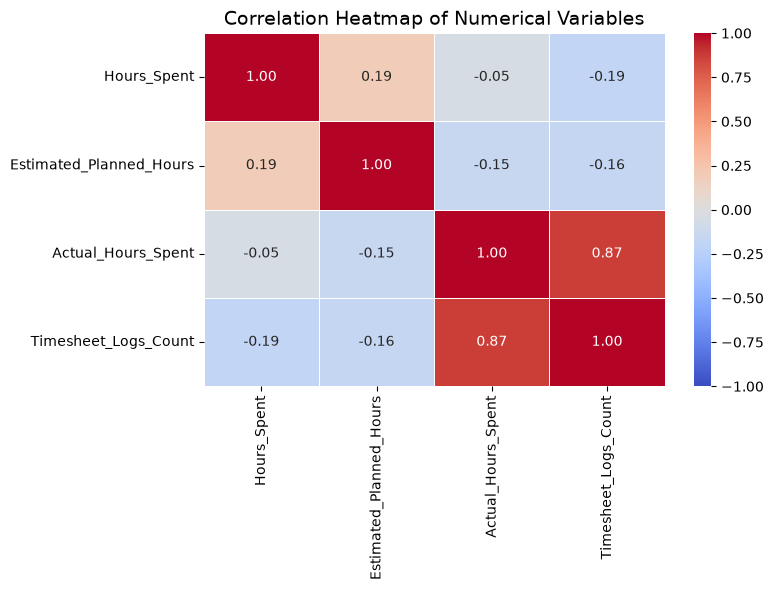

In [104]:
numerical_cols = ['Hours_Spent', 'Estimated_Planned_Hours', 'Actual_Hours_Spent', 'Timesheet_Logs_Count']
corr_matrix = df[numerical_cols].corr()
print("--- Numerical Correlation Matrix ---")
display(corr_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/EDA_Numerical_Correlation_Heatmap.png', dpi=300)
plt.show()

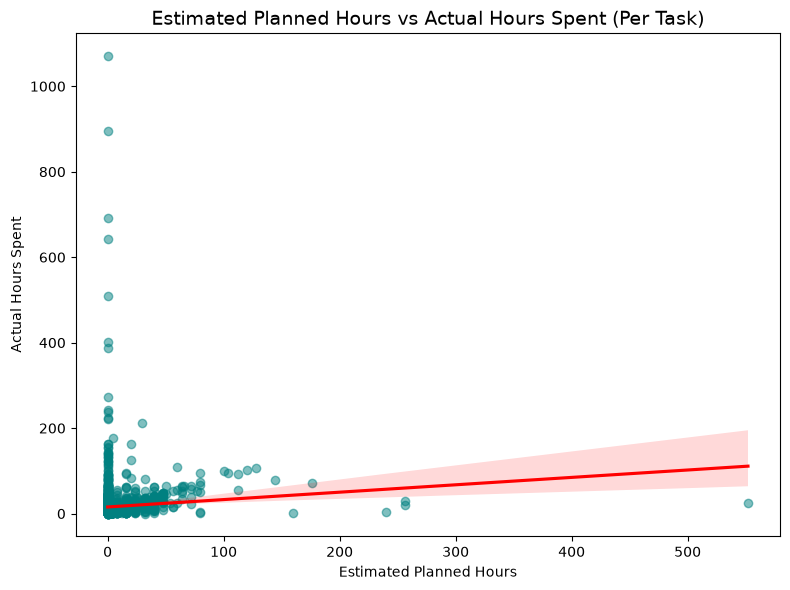

In [105]:
task_hours = df.groupby('Task_ID')[['Estimated_Planned_Hours', 'Actual_Hours_Spent']].max()
plt.figure(figsize=(8, 6))
sns.regplot(
    x='Estimated_Planned_Hours', 
    y='Actual_Hours_Spent', 
    data=task_hours, 
    scatter_kws={'alpha':0.5, 'color':'teal'}, 
    line_kws={'color':'red'}
)
plt.title('Estimated Planned Hours vs Actual Hours Spent (Per Task)', fontsize=14)
plt.xlabel('Estimated Planned Hours')
plt.ylabel('Actual Hours Spent')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Estimated_vs_Actual_Regression.png', dpi=300)
plt.show()

/tmp/ipykernel_275556/42034942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


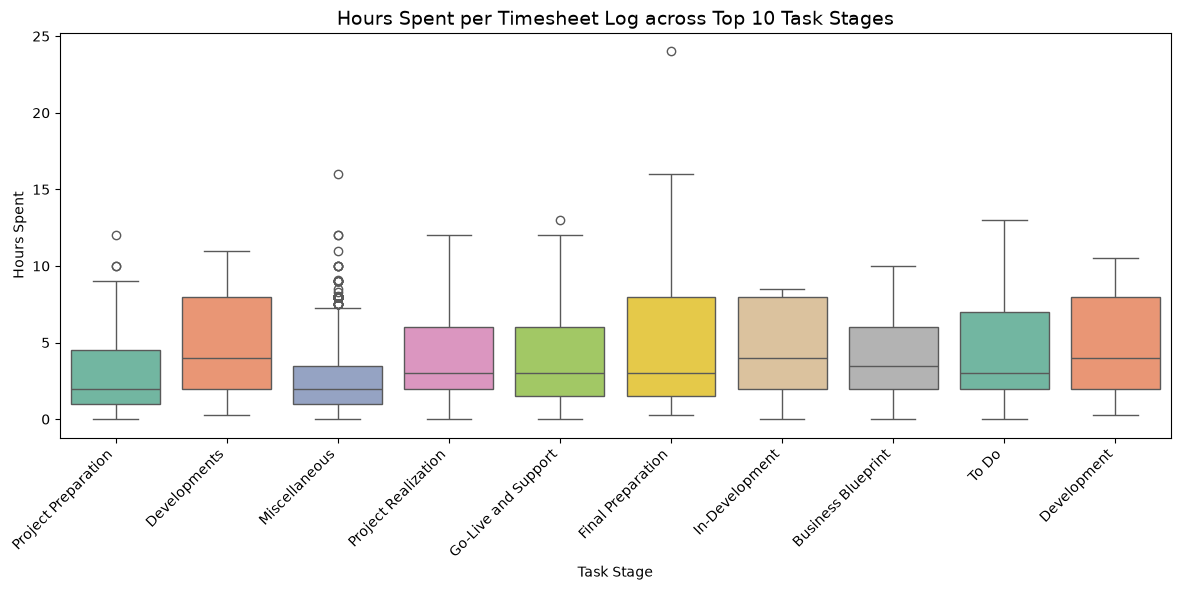

In [106]:
plt.figure(figsize=(12, 6))
top_stages = df['Task_Stage'].value_counts().head(10).index
sns.boxplot(
    x='Task_Stage', 
    y='Hours_Spent', 
    data=df[df['Task_Stage'].isin(top_stages)], 
    palette='Set2'
)
plt.title('Hours Spent per Timesheet Log across Top 10 Task Stages', fontsize=14)
plt.xlabel('Task Stage')
plt.ylabel('Hours Spent')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Hours_vs_TaskStage_Boxplot.png', dpi=300)
plt.show()

/tmp/ipykernel_275556/2393244396.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


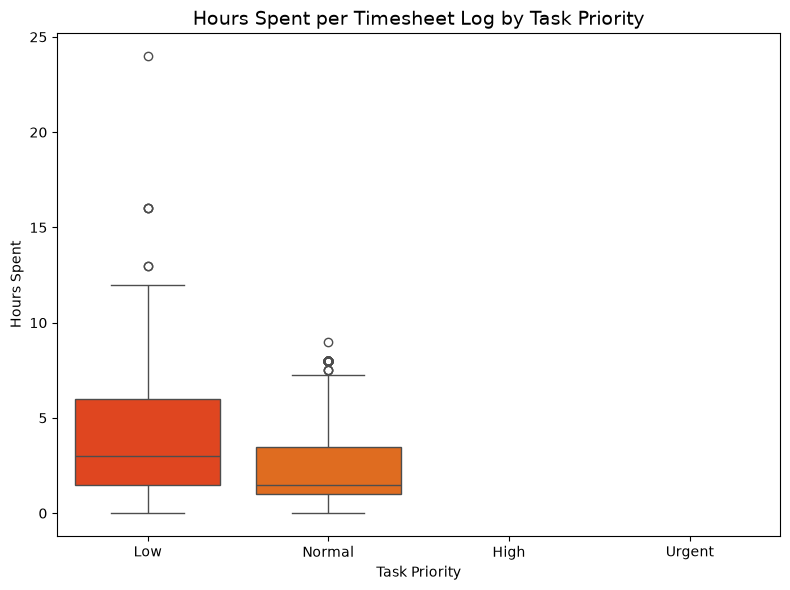

In [107]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='Task_Priority', 
    y='Hours_Spent', 
    data=df, 
    order=['Low', 'Normal', 'High', 'Urgent'],
    palette='autumn'
)
plt.title('Hours Spent per Timesheet Log by Task Priority', fontsize=14)
plt.xlabel('Task Priority')
plt.ylabel('Hours Spent')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Hours_vs_Priority_Boxplot.png', dpi=300)
plt.show()


--- Task Assignments: Department vs Job Position ---


Employee_Job_Position,Assistent Project Manager,Associate Functional Consultant,Associate Software Engineer,Associate pre Sales Consultant,Financial Executive,Functional Support Executive,HOD - Business Solutions,HOD - Research and Development (R&D),Odoo Functional Consultant,Project Manager,...,Sales & Marketing Executive,Senior Support Executive,Senior Support Executive l,Software Engineer,Software Engineer,Support Intern,Team Lead - Research and Development (R&D),Training Odoo Functional Consultant,Training Quality assurance,Training Software Engineer - Internship
Employee_Department,,,,,,,,,,,,,,,,,,,,,
Administration,0,0,0,0,9,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
Business Solution,119,1162,0,0,0,0,1010,0,1448,0,...,0,0,0,0,0,0,0,220,0,0
Colombo Branch,0,321,0,0,0,0,0,0,0,384,...,0,0,0,0,0,166,0,81,0,0
Quality assurance (QA),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,34,0
Research and Development (R&D),0,0,1866,0,0,0,0,176,0,0,...,0,0,0,147,484,0,1444,0,0,670
Sales & Marketing,0,0,0,15,0,0,0,0,0,0,...,50,0,0,0,0,0,0,0,0,0
Support & Maintenance,0,0,0,0,0,516,0,0,0,0,...,0,547,528,92,0,0,0,0,0,0


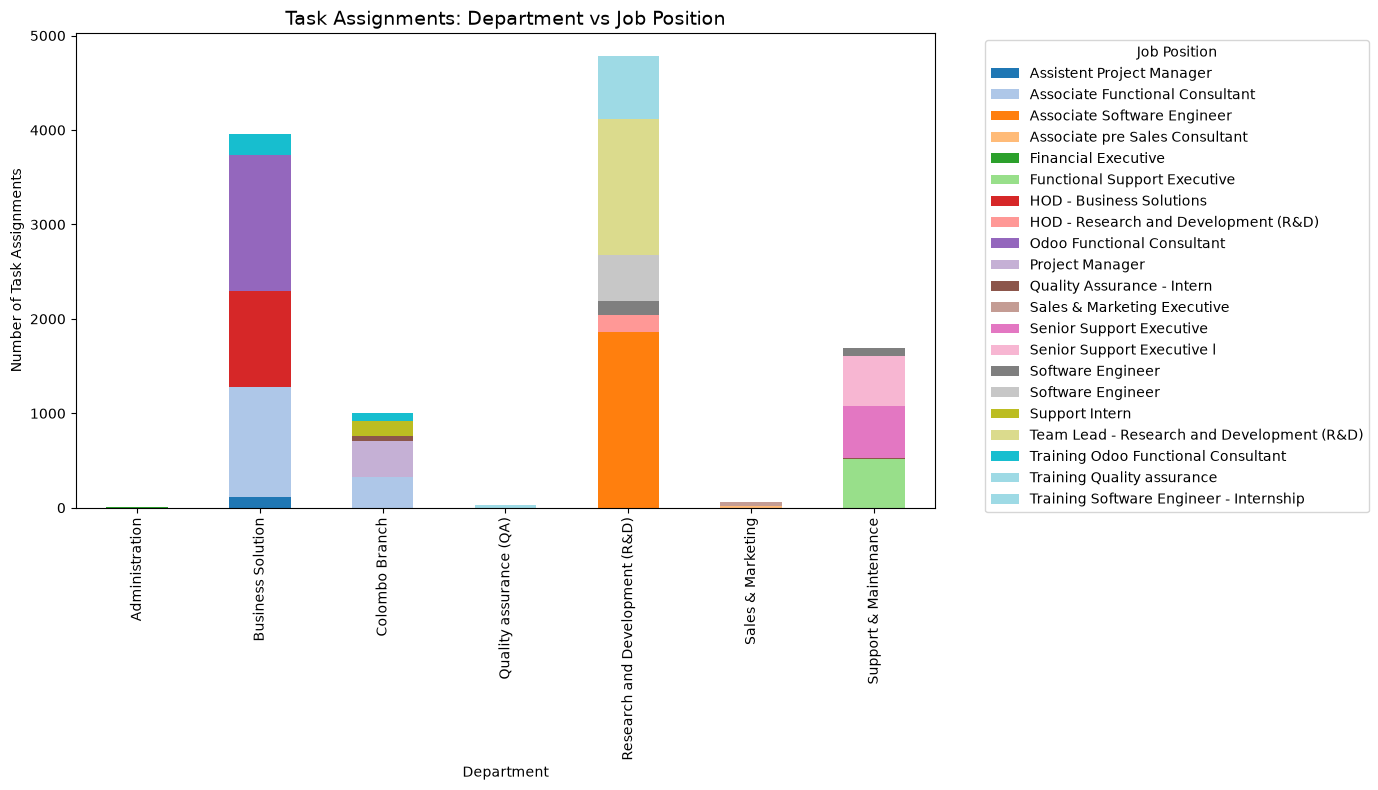

In [108]:
dept_job_ct = pd.crosstab(df['Employee_Department'], df['Employee_Job_Position'])
print("\n--- Task Assignments: Department vs Job Position ---")
display(dept_job_ct)
dept_job_ct.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')
plt.title('Task Assignments: Department vs Job Position', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Number of Task Assignments')
plt.legend(title='Job Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Assignments_Dept_vs_JobPosition.png', dpi=300)
plt.show()


--- Cross-tabulation: Top 5 Employees vs Top 5 Projects ---


Project_Name,Cygnus One,Hovael Project,Milanka Investment - Odoo 18 Implementation,S00196 -Sewinco,S00198 - Water Mart
Employee_Name,,,,,
G L Sachini,153,0,0,65,0
H.M.C.S Thilakarathna,138,0,0,0,0
J A P Swarnamali,339,0,29,78,39
M H R Chandrasoma,128,46,145,48,59
W M I L Wijesinghe,457,32,10,7,3


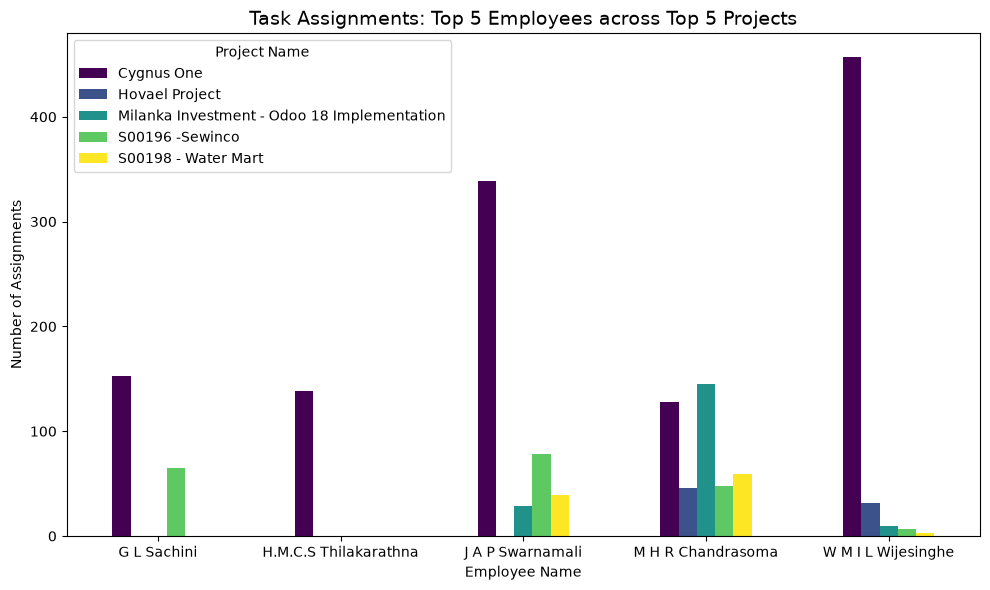

In [109]:
top_5_emps = df['Employee_Name'].value_counts().head(5).index
top_5_projs = df['Project_Name'].value_counts().head(5).index
emp_proj_rel = pd.crosstab(
    df[df['Employee_Name'].isin(top_5_emps)]['Employee_Name'], 
    df[df['Project_Name'].isin(top_5_projs)]['Project_Name']
)
print("\n--- Cross-tabulation: Top 5 Employees vs Top 5 Projects ---")
display(emp_proj_rel)
emp_proj_rel.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Task Assignments: Top 5 Employees across Top 5 Projects', fontsize=14)
plt.xlabel('Employee Name')
plt.ylabel('Number of Assignments')
plt.xticks(rotation=0)
plt.legend(title='Project Name')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Employee_vs_Project_GroupedBar.png', dpi=300)
plt.show()

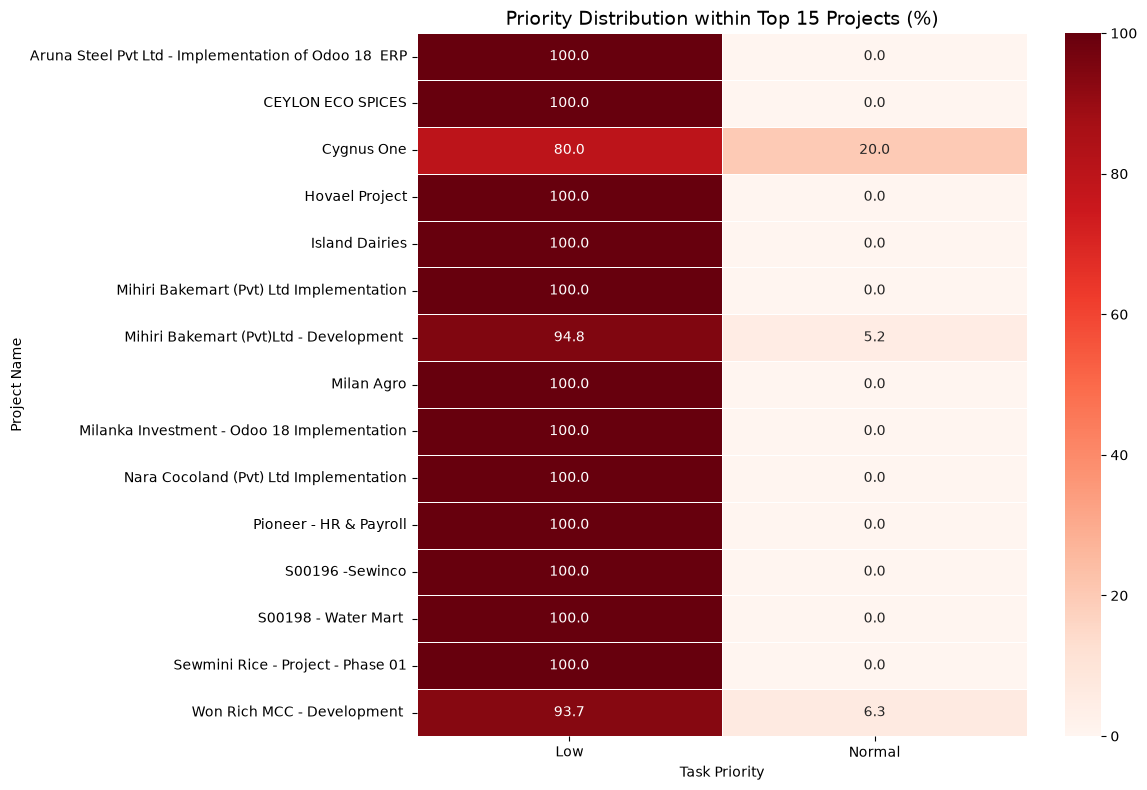

In [110]:
top_15_projs = df['Project_Name'].value_counts().head(15).index
proj_priority_ct = pd.crosstab(
    df[df['Project_Name'].isin(top_15_projs)]['Project_Name'], 
    df['Task_Priority']
)
proj_priority_pct = proj_priority_ct.div(proj_priority_ct.sum(axis=1), axis=0) * 100
plt.figure(figsize=(12, 8))
sns.heatmap(proj_priority_pct, annot=True, fmt=".1f", cmap="Reds", linewidths=0.5)
plt.title('Priority Distribution within Top 15 Projects (%)', fontsize=14)
plt.xlabel('Task Priority')
plt.ylabel('Project Name')
plt.tight_layout()
plt.savefig('../results/figures/EDA_Project_vs_Priority_Heatmap.png', dpi=300)
plt.show()

---

## Step 11: Data Integration Validation

Since the dataset was created by combining two CSV files (in `Data_Preparation.ipynb`), verify that the integration was successful.

**Check:**
- Matching `Task_ID` records between the two source datasets.
- Number of matched and unmatched records.
- Whether the merge created unexpected duplicate records.
- Whether any important information was lost during merging.
- Whether the resulting 11,633 rows are logically consistent.
- Whether columns originating from each dataset contain expected values.

> Document any issues found during the integration process.

In [111]:
timesheet_path = '../data/raw/Employee_Timesheets_Detailed_Dataset.csv'
task_path = '../data/raw/Employee_Task_Allocation_Dataset.csv'
combined_path = '../data/raw/Combined_Employee_Task_Data.csv'
df_timesheet = pd.read_csv(timesheet_path)
df_tasks = pd.read_csv(task_path)
df_combined = pd.read_csv(combined_path)
print("--- 1. Matching and Unmatched Task_ID Records ---")
ts_task_ids = set(df_timesheet['Task_ID'].dropna())
master_task_ids = set(df_tasks['Task_ID'].dropna())
matched_ids = ts_task_ids.intersection(master_task_ids)
unmatched_in_ts = ts_task_ids - master_task_ids
unmatched_in_master = master_task_ids - ts_task_ids
print(f"Unique Task_IDs in Timesheets: {len(ts_task_ids)}")
print(f"Unique Task_IDs in Task Master: {len(master_task_ids)}")
print(f"Task_IDs successfully matched: {len(matched_ids)}")
print(f"Task_IDs in Timesheets but MISSING in Task Master (Unmapped): {len(unmatched_in_ts)}")
print(f"Task_IDs in Task Master with NO timesheet logs: {len(unmatched_in_master)}\n")

--- 1. Matching and Unmatched Task_ID Records ---
Unique Task_IDs in Timesheets: 2442
Unique Task_IDs in Task Master: 3356
Task_IDs successfully matched: 2442
Task_IDs in Timesheets but MISSING in Task Master (Unmapped): 0
Task_IDs in Task Master with NO timesheet logs: 914



In [112]:
print("--- 2. Checking for Unexpected Duplicates ---")
expected_rows = len(df_timesheet)
actual_rows = len(df_combined)
print(f"Original Timesheet Rows: {expected_rows}")
print(f"Combined Dataset Rows: {actual_rows}")
if expected_rows == actual_rows:
    print("Success: No unexpected row multiplication occurred during the merge.")
else:
    print(f"Warning: Row count mismatch! The merge created {actual_rows - expected_rows} unexpected rows.")
is_task_unique = df_tasks['Task_ID'].is_unique
print(f"Are Task_IDs strictly unique in the Task Master dataset? {is_task_unique}\n")

--- 2. Checking for Unexpected Duplicates ---
Original Timesheet Rows: 11633
Combined Dataset Rows: 11633
Success: No unexpected row multiplication occurred during the merge.
Are Task_IDs strictly unique in the Task Master dataset? True



In [113]:
print("--- 3. Checking for Lost Information ---")
task_specific_cols = ['Task_Description', 'Task_Priority', 'Estimated_Planned_Hours', 'Task_Stage']
print("Null values in columns sourced from Task Master (Indicates unmapped tasks):")
missing_task_info = df_combined[task_specific_cols].isnull().sum()
display(missing_task_info.to_frame(name='Missing Values After Merge'))
unmapped_rows_count = len(df_combined[df_combined['Task_ID'].isin(unmatched_in_ts)])
print(f"Total timesheet records affected by unmapped Task_IDs: {unmapped_rows_count} out of {actual_rows} ({unmapped_rows_count/actual_rows*100:.2f}%)\n")

--- 3. Checking for Lost Information ---
Null values in columns sourced from Task Master (Indicates unmapped tasks):


,Missing Values After Merge
Task_Description,0
Task_Priority,0
Estimated_Planned_Hours,0
Task_Stage,0


Total timesheet records affected by unmapped Task_IDs: 0 out of 11633 (0.00%)



In [114]:
print("--- 4. Logical Consistency Validation ---")
ts_ids_original = set(df_timesheet['Timesheet_ID'])
ts_ids_combined = set(df_combined['Timesheet_ID'])
print(f"All 11,633 original Timesheet_IDs retained? {ts_ids_original == ts_ids_combined}")
expected_cols = 22
actual_cols = len(df_combined.columns)
print(f"Expected combined columns: {expected_cols}")
print(f"Actual combined columns: {actual_cols}")
print(f"Column count matches expectations? {expected_cols == actual_cols}\n")

--- 4. Logical Consistency Validation ---
All 11,633 original Timesheet_IDs retained? True
Expected combined columns: 22
Actual combined columns: 22
Column count matches expectations? True



In [115]:
print("--- 5. Integration Validation Summary & Documentation ---")
validation_issues = []
if len(unmatched_in_ts) > 0:
    validation_issues.append(
        f"ISSUE 1: {len(unmatched_in_ts)} unique Task_IDs logged in the timesheets do not exist in the Task Master. "
        f"This leaves {unmapped_rows_count} historical task logs without critical enriched features (Priority, Stage, NLP Descriptions)."
    )
if not is_task_unique:
    validation_issues.append(
        "ISSUE 2: The Task Master contains duplicate Task_IDs. This violates the assumption of a 1:1 unique task master "
        "and could lead to Cartesian row multiplication if those specific duplicate tasks are logged in the timesheet."
    )
if actual_rows != expected_rows:
     validation_issues.append(
         f"ISSUE 3: The merged dataset has {actual_rows} rows, but the original timesheet dataset had {expected_rows}. "
         "The left join multiplied rows, confirming duplicate Task_IDs exist in the right table (Task Master)."
     )
if not validation_issues:
    print("Integration Validated: No data loss, no unexpected row duplication, and perfect relational mapping between datasets.")
else:
    print("The following issues must be documented and addressed in the Data Preprocessing notebook:")
    for issue in validation_issues:
        print(f"- {issue}")

--- 5. Integration Validation Summary & Documentation ---
Integration Validated: No data loss, no unexpected row duplication, and perfect relational mapping between datasets.


---

## Step 12: Key Findings and EDA Conclusions

At the end of the EDA, summarize the major findings.

The conclusion should identify:

| Category | Finding |
|---|---|
| **Dataset** | Size, shape, column types |
| **Data Quality** | Missing value patterns, duplicate/inconsistency issues |
| **Employees** | Distribution patterns, dominating employees, department breakdown |
| **Tasks & Projects** | Common task types, project distributions, priority/stage patterns |
| **Workload & Time** | Hours distributions, planned vs actual gaps, monthly trends |
| **Employee–Task Patterns** | Historical allocation patterns useful for prediction |
| **Text Data** | Quality of description fields, word length statistics |
| **Target Variable** | Class distribution, imbalance level, rare-class employees |
| **Leakage Risks** | Columns to investigate before modelling (`Actual_Hours_Spent`, `Task_Stage`) |
| **Redundant Columns** | Columns to drop before feature engineering |
| **Preprocessing Needs** | Requirements for the next notebook stage |

> Use the EDA findings to define the requirements for:
>
> **Data Preprocessing → Feature Engineering → Baseline → Model Training → Model Evaluation → Hyperparameter Tuning → Employee Recommendation System**

---

## ✅ What Has Been Done in This Notebook

| Step | Section | Status |
|---|---|---|
| 1 | Dataset Overview | ✅ Completed |
| 2 | Data Quality Analysis | ✅ Completed |
| 3 | Employee Analysis | ✅ Completed |
| 4 | Task Analysis | ✅ Completed |
| 5 | Time & Effort Analysis | ✅ Completed |
| 6 | Project Analysis | ✅ Completed |
| 7 | Employee–Task Relationship | ✅ Completed |
| 8 | Text Data Analysis | ✅ Completed |
| 9 | Target Variable Analysis | ✅ Completed |
| 10 | Correlation & Relationships | ✅ Completed |
| 11 | Data Integration Validation | ✅ Completed |
| 12 | Key Findings & Conclusions | ✅ Completed |

---

## 🔲 What Comes Next (Next Notebook)

Based on EDA findings, the next notebook (`03_Preprocessing.ipynb`) will cover:

| Step | Task |
|---|---|
| Preprocessing | Handle missing values per EDA findings |
| Preprocessing | Encode categorical columns |
| Preprocessing | Normalise numerical columns |
| Preprocessing | Clean text columns (lowercase, stop-words, punctuation) |
| Preprocessing | Resolve data leakage risks (`Actual_Hours_Spent`, `Task_Stage`) |
| Preprocessing | Train / test split |
| Feature Engineering | TF-IDF on task descriptions |
| Feature Engineering | Employee aggregate features |
| Feature Engineering | Employee–task relationship features |
| Modelling | Baseline → Logistic Regression → Random Forest → XGBoost |
| Evaluation | Top-1, Top-3, Top-5 Hit Rate + Accuracy, F1, ROC-AUC |